# Run an original or retrained Chronos model and measure probing space saving

**Run all in Colab. No input table or repository checkout is needed.** Select `MODEL_SOURCE = "retrained"` or `"published"` for the original
`amazon/chronos-bolt-tiny`. The original requires `P, S = 16, 16`; retrained checkpoints use
the selected `P` and `S` (default: `p16-s16-seed42`). The notebook downloads that checkpoint, generates pure
sinusoids, makes real forecasts while capturing encoder and decoder states, runs MDL on seven frequency-band
tasks, and saves the decoder figure plus a separate encoder-only figure.

The Appendix F supplement also reads the existing local per-frequency MDL collection. In Colab it downloads
the pinned repository artifact automatically, so it is not an input that you have to find. That collection is
historical retrained data and is labelled separately from the fresh model-prediction run above.

Use a Colab GPU for model inference. The linear MDL probes run on CPU. `SMOKE = True` makes a small
run with the **same real checkpoint**, stored and labelled separately; it is only a runtime check.
With `SAVE_TO_DRIVE = True`, outputs are written to Drive. No model is trained or retrained here.

Both fresh model sources use the same generated inputs, seeds, probe stages, and MDL procedure.
Output folders, figure labels, and provenance distinguish original and retrained weights.
Changing the source changes only the checkpoint; it does not reproduce the paper's estimator. The fresh
band-task figures follow [Pagani et al., Figure 3](https://arxiv.org/html/2605.06361v1), but the estimator is the repository's
five-chunk prequential MDL with scaling, PCA(20), and logistic regression, rather than the paper's
replay-based online estimator. The uniformly encoded first chunk gives an SV ceiling near 0.8.
Each control permutes the same task's labels on the same features, with identical coding chunks.

The Appendix F plots are descriptive profiles of locked versus non-locked local codelength. They do not
replace the fresh model-prediction run and do not provide a hypothesis test.


In [33]:
# Standalone dependencies: no imports from the patchAliasing checkout.
import importlib.util
import subprocess
import sys
packages = {"numpy": "numpy", "pandas": "pandas", "pyarrow": "pyarrow", "matplotlib": "matplotlib",
            "sklearn": "scikit-learn", "torch": "torch", "huggingface_hub": "huggingface-hub",
            "accelerate": "accelerate", "chronos": "chronos-forecasting", "tqdm": "tqdm"}
missing = []
for module, package in packages.items():
    spec = importlib.util.find_spec(module)
    if spec is None or (module == "chronos" and spec.origin is None):
        missing.append(package)
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    importlib.invalidate_caches()
    # A local folder named chronos may have been imported as a namespace before installation.
    if "chronos" in sys.modules and not getattr(sys.modules["chronos"], "__file__", None):
        del sys.modules["chronos"]

from pathlib import Path
from datetime import datetime, timezone
from math import gcd
import hashlib
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from huggingface_hub import snapshot_download
from chronos import BaseChronosPipeline
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from threadpoolctl import threadpool_limits
from tqdm.auto import tqdm
from IPython.display import Image, display


In [34]:
# ---- choose the checkpoint and experiment ---------------------------------------
MODEL_SOURCE = "published"  # "retrained" or "published" (original Amazon model)
P, S = 16, 16
LOCAL_MODEL_DIR = None  # Optional finished checkpoint directory; otherwise download from HF.
PUBLISHED_ID = "amazon/chronos-bolt-tiny"
PUBLISHED_REVISION = "a0e552de83495b5c28c14c71c374f3e33280b340"
SWEEP_REPO = "federicosabbadini/chronos-bolt-patch-sweep"
SWEEP_REVISION = "230ea28278a3c60621964b920e9778c0ba73337e"  # same immutable revision as model_loader.py

SEED = 42
FS = 512
CONTEXT_LENGTH = 512
FREQUENCY_STEP = 1           # Hz, over [2, 250]
MAX_PHASE_SHIFTS = 32       # capped separately by fs/gcd(f,fs)-1 for each frequency
BATCH_SIZE = 64
MDL_CHUNKS = 5
PCA_COMPONENTS = 20
CPU_THREADS = 2             # limits BLAS oversubscription during the small linear fits
SMOKE = False
SAVE_TO_DRIVE = True
OUTPUT_ROOT = None          # Optional output folder. No existing data are required.

BAND_TASKS = [("LL", 2, 64, 33), ("L", 2, 126, 64), ("LH", 65, 126, 95),
              ("Mid", 2, 250, 126), ("HL", 127, 188, 157),
              ("H", 127, 250, 188), ("HH", 189, 250, 219)]
TASK_ORDER = [task[0] for task in BAND_TASKS]
if MODEL_SOURCE not in {"retrained", "published"}:
    raise ValueError('MODEL_SOURCE must be "retrained" or "published".')
if MODEL_SOURCE == "published" and (P, S) != (16, 16):
    raise ValueError("The original Chronos-Bolt-Tiny has P=S=16; set P, S = 16, 16.")
if MODEL_SOURCE == "published" and LOCAL_MODEL_DIR is not None:
    raise ValueError("LOCAL_MODEL_DIR applies only to retrained checkpoints; set it to None for published.")
MODEL_LABEL = "original Amazon" if MODEL_SOURCE == "published" else "retrained"
GEOMETRY = f"p{P}-s{S}"
if not (isinstance(P, int) and isinstance(S, int) and 0 < S <= P):
    raise ValueError("Require integer patch/stride with 0 < S <= P.")
for name in ("CONTEXT_LENGTH", "FREQUENCY_STEP", "MAX_PHASE_SHIFTS", "BATCH_SIZE", "PCA_COMPONENTS", "CPU_THREADS"):
    if not isinstance(globals()[name], int) or globals()[name] < 1:
        raise ValueError(f"{name} must be a positive integer.")
if not isinstance(MDL_CHUNKS, int) or MDL_CHUNKS < 2:
    raise ValueError("MDL_CHUNKS must be an integer >= 2.")
if SMOKE:
    FREQUENCY_STEP, MAX_PHASE_SHIFTS = 16, 4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
np.random.seed(SEED); torch.manual_seed(SEED)
if DEVICE == "cpu":
    torch.set_num_threads(CPU_THREADS)

def in_colab():
    try:
        return importlib.util.find_spec("google.colab") is not None
    except ModuleNotFoundError:
        return False

if OUTPUT_ROOT is None and SAVE_TO_DRIVE and in_colab():
    from google.colab import drive
    if not Path("/content/drive/MyDrive").is_dir():
        drive.mount("/content/drive")
    base = Path("/content/drive/MyDrive/patchAliasing/probing_space_saving")
else:
    base = Path(OUTPUT_ROOT).expanduser() if OUTPUT_ROOT else Path.cwd() / "_run" / "probing_space_saving"
RUN_KIND = "SMOKE" if SMOKE else "FULL"
OUT = base / RUN_KIND.lower() / f"{MODEL_SOURCE}_{GEOMETRY}_{datetime.now(timezone.utc):%Y%m%dT%H%M%S%fZ}"
(OUT / "figures").mkdir(parents=True, exist_ok=True)
print(f"{RUN_KIND}: {MODEL_LABEL} {GEOMETRY}, device={DEVICE}; output: {OUT}")


FULL: original Amazon p16-s16, device=cpu; output: c:\Users\bonio\dev\patchAliasing\chronos\bayesian\_run\probing_space_saving\full\published_p16-s16_20260908T151450185709Z


## 1. Load and verify the selected checkpoint


In [35]:
def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def load_model():
    subfolder = f"p{P}-s{S}-seed42"
    if MODEL_SOURCE == "published":
        model_dir = Path(snapshot_download(PUBLISHED_ID, revision=PUBLISHED_REVISION,
                                           allow_patterns=["config.json", "model.safetensors"]))
        identity = {"source": "huggingface", "repo": PUBLISHED_ID, "revision": PUBLISHED_REVISION}
    elif LOCAL_MODEL_DIR is not None:
        model_dir = Path(LOCAL_MODEL_DIR).expanduser().resolve()
        identity = {"source": "local", "path": str(model_dir)}
    else:
        snapshot = snapshot_download(SWEEP_REPO, revision=SWEEP_REVISION,
                                     allow_patterns=[f"{subfolder}/*"])
        model_dir = Path(snapshot) / subfolder
        identity = {"source": "huggingface", "repo": SWEEP_REPO,
                    "revision": SWEEP_REVISION, "subfolder": subfolder}
    required = ["config.json", "model.safetensors"]
    if MODEL_SOURCE == "retrained":
        required.append("run_config.json")
    identity["model_source"] = MODEL_SOURCE
    absent = [name for name in required if not (model_dir / name).is_file()]
    if absent:
        raise FileNotFoundError(f"Incomplete selected checkpoint at {model_dir}: missing {absent}")
    config = json.loads((model_dir / "config.json").read_text())
    run_config = (json.loads((model_dir / "run_config.json").read_text())
                  if MODEL_SOURCE == "retrained" else None)
    def values_for(obj, key):
        if isinstance(obj, dict):
            return ([obj[key]] if key in obj else []) + [v for child in obj.values() for v in values_for(child, key)]
        if isinstance(obj, list):
            return [v for child in obj for v in values_for(child, key)]
        return []
    for key, expected in (("seed", 42), ("steps_completed", 100000)):
        if any(int(v) != expected for v in values_for(run_config, key)):
            raise ValueError(f"Retrained checkpoint {key} does not match {expected}.")
    if any(str(v).lower() not in {"done", "complete", "completed", "finished"}
           for v in values_for(run_config, "status")):
        raise ValueError("The selected checkpoint's training run is not complete.")
    cc = config["chronos_config"]
    actual = (int(cc["input_patch_size"]), int(cc["input_patch_stride"]))
    if actual != (P, S):
        raise ValueError(f"Requested {(P, S)}, checkpoint declares {actual}")
    if CONTEXT_LENGTH > int(cc["context_length"]):
        raise ValueError("Requested context exceeds the checkpoint's context_length.")
    if int(cc["prediction_length"]) != 64 or 0.5 not in cc["quantiles"]:
        raise ValueError("Expected a 64-step forecast with a median quantile.")
    identity["sha256"] = {name: sha256_file(model_dir / name) for name in required}
    identity["run_config"] = run_config
    pipe = BaseChronosPipeline.from_pretrained(str(model_dir), device_map=DEVICE, torch_dtype=torch.float32)
    pipe.model.eval()
    for parameter in pipe.model.parameters():
        parameter.requires_grad_(False)
    if not hasattr(pipe.model, "output_patch_embedding"):
        raise TypeError("Loaded model does not have the expected Chronos-Bolt output head.")
    return pipe, cc, identity

PIPE, MODEL_CONFIG, CHECKPOINT = load_model()
PREDICTION_LENGTH = int(MODEL_CONFIG["prediction_length"])
MEDIAN_INDEX = list(MODEL_CONFIG["quantiles"]).index(0.5)
PAPER_STAGES = [f"dec_{i}" for i in range(len(PIPE.model.decoder.block))] + ["output_head"]
SOURCE_NOTE = f"{RUN_KIND} | {MODEL_LABEL} {GEOMETRY} | seed {SEED} | MDL K={MDL_CHUNKS}"
print("Loaded:", CHECKPOINT.get("subfolder", CHECKPOINT.get("path", CHECKPOINT.get("repo"))), "stages:", PAPER_STAGES)


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loaded: amazon/chronos-bolt-tiny stages: ['dec_0', 'dec_1', 'dec_2', 'dec_3', 'output_head']


## 2. Generate the inputs

For each integer frequency, use distinct integer-sample shifts of a pure sinusoid. The cap is
`min(fs/gcd(f, fs) - 1, MAX_PHASE_SHIFTS)`. Context and future are slices of the same sinusoid;
there are no generator backgrounds. Samples at a given frequency may occur in different MDL
chunks, but exact phase configurations are never duplicated. This measures band readability
across phases, not generalisation to entirely unseen frequencies.


In [36]:
def make_signals(fs, context_length, prediction_length, frequency_step, max_shifts):
    contexts, futures, frequencies, shifts = [], [], [], []
    samples = np.arange(context_length + prediction_length, dtype=np.float64)
    for f in np.arange(2, 251, frequency_step, dtype=int):
        period = fs // gcd(int(f), fs)
        count = min(period - 1, max_shifts)
        for shift in range(count):
            # Integer modular phase avoids spurious differences between periodic duplicates.
            phase = np.remainder(f * (samples + shift), fs) / fs
            signal = np.sin(2 * np.pi * phase).astype(np.float32)
            contexts.append(signal[:context_length]); futures.append(signal[context_length:])
            frequencies.append(f); shifts.append(shift)
    return np.stack(contexts), np.stack(futures), np.asarray(frequencies), np.asarray(shifts)

CONTEXTS, TRUE_FUTURES, FREQUENCIES, SHIFTS = make_signals(
    FS, CONTEXT_LENGTH, PREDICTION_LENGTH, FREQUENCY_STEP, MAX_PHASE_SHIFTS)
for name, lo, hi, boundary in BAND_TASKS:
    mask = (FREQUENCIES >= lo) & (FREQUENCIES <= hi)
    labels = (FREQUENCIES[mask] > boundary).astype(int)
    if len(labels) < MDL_CHUNKS or len(np.unique(labels)) != 2:
        raise ValueError(f"{name}: not enough examples/classes. Use a finer frequency grid.")
print(f"{len(CONTEXTS):,} contexts; {len(np.unique(FREQUENCIES))} frequencies; "
      f"{int(np.ceil(len(CONTEXTS) / BATCH_SIZE))} inference batches")
print(f"MDL: {len(BAND_TASKS) * len(PAPER_STAGES)} task/stage pairs, "
      f"up to {2 * (MDL_CHUNKS - 1) * len(BAND_TASKS) * len(PAPER_STAGES)} logistic fits including controls")
MANIFEST = dict(run_kind=RUN_KIND, model_source=MODEL_SOURCE, geometry=dict(P=P, S=S), seed=SEED, fs=FS,
                context_length=CONTEXT_LENGTH, prediction_length=PREDICTION_LENGTH,
                frequency_step=FREQUENCY_STEP, max_phase_shifts=MAX_PHASE_SHIFTS,
                n_contexts=len(CONTEXTS), mdl_chunks=MDL_CHUNKS, pca_components=PCA_COMPONENTS,
                checkpoint=CHECKPOINT, stages=PAPER_STAGES, tasks=BAND_TASKS,
                versions={"torch": torch.__version__, "numpy": np.__version__,
                          "sklearn": __import__("sklearn").__version__}, status="inference_pending")
(OUT / "run_config.json").write_text(json.dumps(MANIFEST, indent=2) + "\n", encoding="utf-8")


7,813 contexts; 249 frequencies; 123 inference batches
MDL: 35 task/stage pairs, up to 280 logistic fits including controls


1328

## 3. Make forecasts and capture decoder representations in the same forward pass


In [37]:
def forecast_and_capture(pipe, contexts, batch_size, device, median_index, prediction_length):
    model = pipe.model
    stages = [f"dec_{i}" for i in range(len(model.decoder.block))] + ["output_head"]
    captured, pieces, predictions = {}, {s: [] for s in stages}, []
    handles = []
    def capture(stage):
        def hook(module, args, output):
            value = output[0] if isinstance(output, tuple) else output
            if value.ndim == 3:
                if value.shape[1] != 1:
                    raise ValueError(f"{stage}: expected one decoder query, got {tuple(value.shape)}")
                value = value[:, 0, :]
            if value.ndim != 2:
                raise ValueError(f"{stage}: unexpected shape {tuple(value.shape)}")
            captured[stage] = value.detach().float().cpu().numpy().copy()
        return hook
    try:
        for i, block in enumerate(model.decoder.block):
            handles.append(block.register_forward_hook(capture(f"dec_{i}")))
        handles.append(model.output_patch_embedding.register_forward_hook(capture("output_head")))
        with torch.inference_mode():
            for start in tqdm(range(0, len(contexts), batch_size), desc="Model predictions + states"):
                captured.clear()
                xb = torch.as_tensor(contexts[start:start + batch_size], dtype=torch.float32, device=device)
                forecasts = pipe.predict(xb, prediction_length=prediction_length)
                if forecasts.ndim != 3 or forecasts.shape[0] != len(xb) or forecasts.shape[-1] != prediction_length:
                    raise ValueError(f"Unexpected forecast shape: {tuple(forecasts.shape)}")
                predictions.append(forecasts[:, median_index, :].detach().float().cpu().numpy())
                for stage in stages:
                    if stage not in captured or captured[stage].shape[0] != len(xb):
                        raise RuntimeError(f"Missing or misaligned captured features at {stage}")
                    pieces[stage].append(captured[stage])
    finally:
        for handle in handles:
            handle.remove()
    features = {s: np.concatenate(v) for s, v in pieces.items()}
    prediction = np.concatenate(predictions)
    if not np.isfinite(prediction).all() or any(not np.isfinite(x).all() for x in features.values()):
        raise ValueError("Non-finite predictions or features; MDL was not started.")
    return prediction, features

started = time.monotonic()
PREDICTIONS, FEATURES = forecast_and_capture(
    PIPE, CONTEXTS, BATCH_SIZE, DEVICE, MEDIAN_INDEX, PREDICTION_LENGTH)
np.savez_compressed(OUT / "predictions_and_states.npz", predictions=PREDICTIONS,
                    true_futures=TRUE_FUTURES, frequency_hz=FREQUENCIES, shift_samples=SHIFTS,
                    **FEATURES)
MANIFEST["feature_shapes"] = {s: list(x.shape) for s, x in FEATURES.items()}
MANIFEST["inference_seconds"] = time.monotonic() - started
MANIFEST["status"] = "mdl_pending"
(OUT / "run_config.json").write_text(json.dumps(MANIFEST, indent=2) + "\n", encoding="utf-8")
print("Forecasts:", PREDICTIONS.shape, "features:", MANIFEST["feature_shapes"])
# Forecasting is complete; the CPU probes no longer need the model or its GPU allocation.
del PIPE
if torch.cuda.is_available():
    torch.cuda.empty_cache()


Model predictions + states:   0%|          | 0/123 [00:00<?, ?it/s]

Forecasts: (7813, 64) features: {'dec_0': [7813, 256], 'dec_1': [7813, 256], 'dec_2': [7813, 256], 'dec_3': [7813, 256], 'output_head': [7813, 576]}


## 4. Prequential MDL with shuffled-label controls

Shuffle sample order once, charge the first chunk at one bit per binary label, then encode each
new chunk using a probe trained only on earlier chunks. Scaling and PCA are fitted **inside each
training prefix**. The true and shuffled tasks share the same feature transform because it uses
no labels. Each has its own logistic regression. A one-class training prefix uses a uniform code.

No chunk is scored after training on its labels. This is prequential codelength, not training
accuracy or cross-validation loss. For each row, `SV = 1 - L_bits/n`; negative values are retained.


In [38]:
def mdl_pair(features, labels, shuffled_labels, chunks=5, n_pca=20, seed=42):
    X = np.asarray(features, dtype=float)
    ys = [np.asarray(labels, dtype=int), np.asarray(shuffled_labels, dtype=int)]
    if X.ndim != 2 or any(y.shape != (len(X),) for y in ys) or len(X) < chunks or chunks < 2:
        raise ValueError("MDL needs aligned feature/label arrays and at least one sample per chunk.")
    if not np.isfinite(X).all() or any(not set(np.unique(y)).issubset({0, 1}) for y in ys):
        raise ValueError("MDL requires finite features and binary labels.")
    order = np.random.default_rng(seed).permutation(len(X))
    X = X[order]; ys = [y[order] for y in ys]
    blocks = np.array_split(np.arange(len(X)), chunks)
    costs = np.full(2, float(len(blocks[0])))
    audit = [dict(chunk=0, n_train=0, n_test=len(blocks[0]),
                  bits_true=float(len(blocks[0])), bits_shuffled=float(len(blocks[0])))]
    for k in range(1, chunks):
        train = np.concatenate(blocks[:k]); test = blocks[k]
        usable = [len(np.unique(y[train])) == 2 for y in ys]
        if any(usable) and len(train) >= 2:
            scaler = StandardScaler().fit(X[train])
            train_x = scaler.transform(X[train]); test_x = scaler.transform(X[test])
            n_components = min(n_pca, X.shape[1], len(train) - 1)
            if n_components < 1:
                raise ValueError("Insufficient feature dimension for PCA.")
            pca = PCA(n_components=n_components, svd_solver="randomized", random_state=seed)
            train_x = pca.fit_transform(train_x); test_x = pca.transform(test_x)
        increments = []
        for y, valid in zip(ys, usable):
            if not valid or len(train) < 2:
                bits = float(len(test))
            else:
                clf = LogisticRegression(max_iter=2000, random_state=seed)
                clf.fit(train_x, y[train])
                probability = clf.predict_proba(test_x)
                columns = np.searchsorted(clf.classes_, y[test])
                bits = float(-np.log2(np.clip(probability[np.arange(len(test)), columns], 1e-6, 1)).sum())
            increments.append(bits)
        costs += increments
        audit.append(dict(chunk=k, n_train=len(train), n_test=len(test),
                          bits_true=increments[0], bits_shuffled=increments[1]))
    return float(costs[0]), float(costs[1]), audit


def run_mdl(features, frequencies):
    rows, coding_rows = [], []
    total = len(BAND_TASKS) * len(PAPER_STAGES)
    with threadpool_limits(limits=CPU_THREADS):
        with tqdm(total=total, desc="MDL task/stage pairs") as progress:
            for task_index, (name, lo, hi, boundary) in enumerate(BAND_TASKS):
                mask = (frequencies >= lo) & (frequencies <= hi)
                y = (frequencies[mask] > boundary).astype(int)
                shuffled = np.random.default_rng(SEED + task_index).permutation(y)
                for stage in PAPER_STAGES:
                    bits, control_bits, audit = mdl_pair(features[stage][mask], y, shuffled,
                                                        MDL_CHUNKS, PCA_COMPONENTS, SEED)
                    n = len(y)
                    rows.append(dict(model=GEOMETRY, model_source=MODEL_SOURCE, P=P, S=S, stage=stage, task=name, n=n,
                                     n_class0=int((y == 0).sum()), n_class1=int((y == 1).sum()),
                                     L_bits=bits, L_uniform=float(n), L_shuffled_bits=control_bits,
                                     SV=1 - bits/n, SV_shuffled=1 - control_bits/n,
                                     SV_ceiling=1 - audit[0]["n_test"]/n))
                    coding_rows.extend(dict(model=GEOMETRY, model_source=MODEL_SOURCE, stage=stage, task=name, **r) for r in audit)
                    # Persist completed pairs, so an interrupted cell still leaves auditable work.
                    pd.DataFrame(rows).to_csv(OUT / "space_saving_partial.csv", index=False)
                    progress.update(1)
    return pd.DataFrame(rows), pd.DataFrame(coding_rows)

started = time.monotonic()
BT, CODING = run_mdl(FEATURES, FREQUENCIES)
if BT.duplicated(["model", "stage", "task"]).any() or len(BT) != len(BAND_TASKS) * len(PAPER_STAGES):
    raise RuntimeError("Incomplete or duplicated MDL results.")
np.testing.assert_allclose(BT["SV"], 1 - BT["L_bits"]/BT["n"])
if (BT["SV"] > BT["SV_ceiling"] + 1e-9).any():
    raise RuntimeError("SV exceeds the prequential first-chunk ceiling.")
BT.to_csv(OUT / "02_mdl_bandtasks.csv", index=False)
CODING.to_csv(OUT / "mdl_coding_chunks.csv", index=False)
MANIFEST["mdl_seconds"] = time.monotonic() - started
MANIFEST["status"] = "mdl_complete"
(OUT / "run_config.json").write_text(json.dumps(MANIFEST, indent=2) + "\n", encoding="utf-8")
# Audit the two codes independently, including the initial uniform block.
chunk_totals = CODING.groupby(["stage", "task"])[["bits_true", "bits_shuffled"]].sum().sort_index()
by_pair = BT.set_index(["stage", "task"]).sort_index()
np.testing.assert_allclose(chunk_totals["bits_true"], by_pair["L_bits"])
np.testing.assert_allclose(chunk_totals["bits_shuffled"], by_pair["L_shuffled_bits"])
print(f"First-chunk SV ceiling: {BT.SV_ceiling.min():.6f} to {BT.SV_ceiling.max():.6f}")
print(f"True-label SV: {BT.SV.min():.6f} to {BT.SV.max():.6f}")
print(f"Shuffled-label SV: {BT.SV_shuffled.min():.6f} to {BT.SV_shuffled.max():.6f}")
display(BT.round(6))


MDL task/stage pairs:   0%|          | 0/35 [00:00<?, ?it/s]

First-chunk SV ceiling: 0.799587 to 0.800000
True-label SV: 0.335923 to 0.798509
Shuffled-label SV: -0.031957 to -0.003781


,model,model_source,P,S,stage,task,n,n_class0,n_class1,L_bits,L_uniform,L_shuffled_bits,SV,SV_shuffled,SV_ceiling
0,p16-s16,published,16,16,dec_0,LL,1972,1006,966,414.825261,1972.0,2035.019152,0.789642,-0.031957,0.799696
1,p16-s16,published,16,16,dec_1,LL,1972,1006,966,423.286096,1972.0,2017.839665,0.785352,-0.023245,0.799696
2,p16-s16,published,16,16,dec_2,LL,1972,1006,966,460.342972,1972.0,2022.770017,0.766560,-0.025745,0.799696
3,p16-s16,published,16,16,dec_3,LL,1972,1006,966,490.430119,1972.0,2029.389207,0.751303,-0.029102,0.799696
4,p16-s16,published,16,16,output_head,LL,1972,1006,966,1309.560820,1972.0,2020.631688,0.335923,-0.024661,0.799696
5,p16-s16,published,16,16,dec_0,L,3937,1972,1965,793.269033,3937.0,3960.163855,0.798509,-0.005884,0.799848
6,p16-s16,published,16,16,dec_1,L,3937,1972,1965,802.433630,3937.0,3960.342913,0.796181,-0.005929,0.799848
7,p16-s16,published,16,16,dec_2,L,3937,1972,1965,809.385887,3937.0,3967.815465,0.794416,-0.007827,0.799848
8,p16-s16,published,16,16,dec_3,L,3937,1972,1965,869.325150,3937.0,3971.460244,0.779191,-0.008753,0.799848
9,p16-s16,published,16,16,output_head,L,3937,1972,1965,2586.252853,3937.0,3969.579493,0.343090,-0.008275,0.799848


## 5. Space-saving figure from this run

Each bar is the true-label SV. Parentheses give the **separate shuffled-label SV**, not
`SV - 1` or an error bar. For example, a control of -0.0046 rounds to -0.00 at two decimals;
three decimals are shown here. Full-precision values remain in the CSV.

The red dashed line marks the largest space saving observed in the displayed grid, `max(SV)`.
The **derived ceiling** of the estimator, `1 - ceil(n/5)/n`, is what the five-chunk prequential code
allows at best: the first chunk is charged uniformly before any probe exists, so no representation
can save more than four fifths of the uniform cost. `SV` never exceeds its own ceiling, so a line at
the ceiling would fall on the per-bar labels, which begin at `max(SV)` and run rightwards. It is
therefore reported in the caption and drawn only in the rare case where there is clear space for it. All labels are aligned just after the red line: the
shuffled-label control is in parentheses and `Δ` is the distance from that bar to the maximum.


wrote c:\Users\bonio\dev\patchAliasing\chronos\bayesian\_run\probing_space_saving\full\published_p16-s16_20260908T151450185709Z\figures\FIG_SV_published_p16-s16.png (200 kB)
wrote c:\Users\bonio\dev\patchAliasing\chronos\bayesian\_run\probing_space_saving\full\published_p16-s16_20260908T151450185709Z\figures\FIG_SV_published_p16-s16.pdf (28 kB)


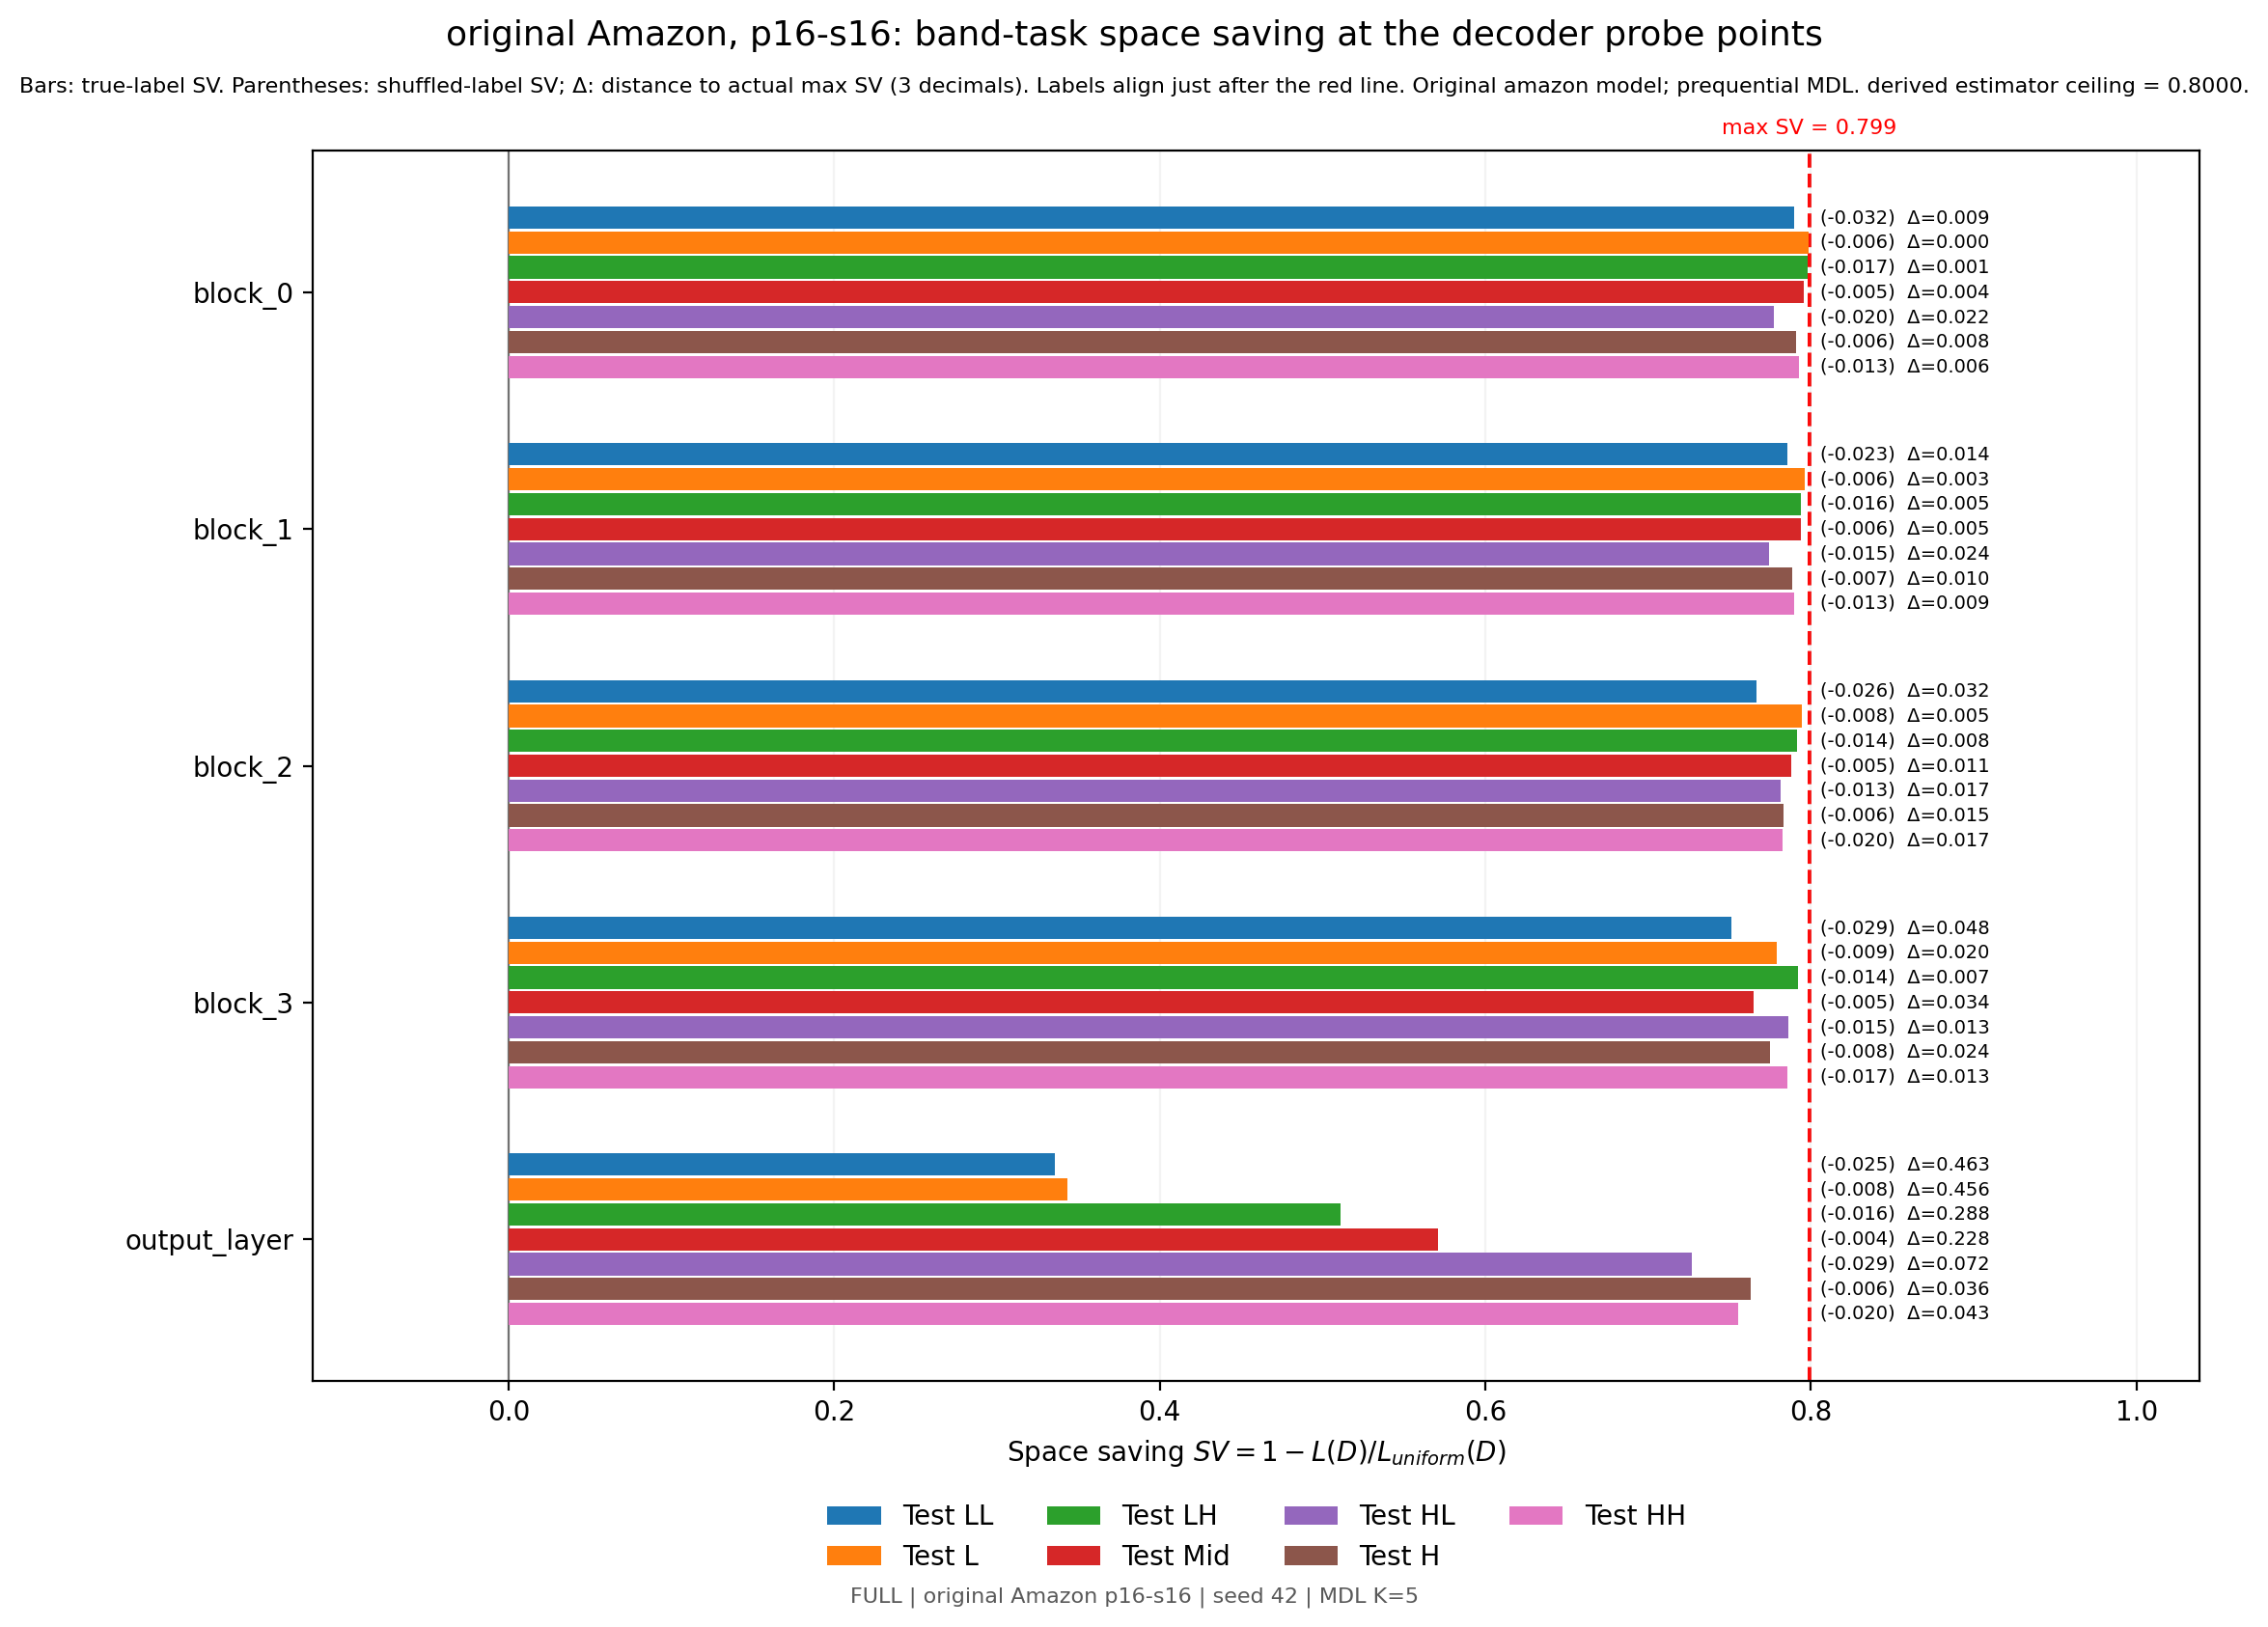

In [39]:
def stage_order(df):
    def key(stage):
        if stage.startswith("enc_"): return (0, int(stage.split("_")[1]))
        if stage.startswith("dec_"): return (1, int(stage.split("_")[1]))
        return (2, ["output_reg", "output_head"].index(stage))
    return sorted(df["stage"].unique(), key=key)


def nice(stage):
    if stage.startswith("enc_"): return f"encoder block {stage.split('_')[1]}"
    if stage.startswith("dec_"): return f"block_{stage.split('_')[1]}"
    return {"output_reg": "pre-projection", "output_head": "output_layer"}[stage]


def complete_grid(table, keys, expected):
    expected_index = pd.MultiIndex.from_product(expected, names=keys)
    indexed = table.set_index(keys)
    missing = expected_index.difference(indexed.index)
    if len(missing):
        raise ValueError(f"Missing measurements for {keys}: {list(missing[:12])}. "
                         "Choose a complete table; missing values are not filled or averaged.")
    return indexed.reindex(expected_index)


def report(path):
    print(f"wrote {path} ({path.stat().st_size / 1024:.0f} kB)")


def save_figure(fig, name):
    path = OUT / "figures" / name
    fig.savefig(path, dpi=200, bbox_inches="tight")
    fig.savefig(path.with_suffix(".pdf"), bbox_inches="tight")
    plt.close(fig)
    report(path); report(path.with_suffix(".pdf"))
    return path

def ceiling_reference(grid):
    """The space saving the estimator itself allows, derived rather than observed.

    Prequential coding charges the first chunk uniformly, before any probe exists, so
    L(D) >= |B_0| and SV <= 1 - |B_0|/n with |B_0| = ceil(n/CHUNKS). It is a property of the
    coding scheme, not of the model: no representation can save more than (CHUNKS-1)/CHUNKS.
    Returns (low, high) over the cells drawn, which differ only in the rounding of n.
    """
    if "SV_ceiling" not in grid.columns:
        return None
    values = grid["SV_ceiling"].to_numpy(float)
    return float(np.nanmin(values)), float(np.nanmax(values))


def ceiling_note(grid, label_x, margin=0.015):
    """Text for the derived ceiling, and whether a vertical line for it can be drawn.

    The per-bar labels begin at `label_x` and run rightwards, and SV never exceeds its own
    ceiling, so a line at the ceiling almost always lands on top of that text. When it would,
    the value is reported in the caption instead of being drawn over the numbers.
    """
    reference = ceiling_reference(grid)
    if reference is None:
        return None, False
    low, high = reference
    text = (f"derived estimator ceiling {low:.4f}-{high:.4f}" if high - low > 5e-4
            else f"derived estimator ceiling = {high:.4f}")
    return (low, high, text), high <= label_x - margin


def spacesaving_page(geometry=GEOMETRY, fname=None):
    d = BT[BT["model"] == geometry]
    if d.empty:
        raise ValueError(f"{geometry} not in the table; available: {sorted(BT['model'].unique())}")
    grid = complete_grid(d, ["stage", "task"], [PAPER_STAGES, TASK_ORDER])
    max_sv = round(float(grid["SV"].max()), 3)
    if not np.isfinite(max_sv) or not (0 <= max_sv <= 1):
        raise ValueError(f"Invalid computed maximum SV: {max_sv}")
    colours = plt.get_cmap("tab10").colors[:len(TASK_ORDER)]
    fig, ax = plt.subplots(figsize=(11.5, 8.5))
    height = 0.105
    ys = np.arange(len(PAPER_STAGES))
    for i, (task, colour) in enumerate(zip(TASK_ORDER, colours)):
        sub = grid.xs(task, level="task").reindex(PAPER_STAGES)
        pos = ys + (i - (len(TASK_ORDER) - 1) / 2) * height
        ax.barh(pos, sub["SV"], height=height * 0.9, color=colour, label=f"Test {task}")
        for y, (_, row) in zip(pos, sub.iterrows()):
            control = row.get("SV_shuffled", np.nan)
            distance = max(0.0, max_sv - float(row["SV"]))
            text = (f"({control:+.3f})  Δ={distance:.3f}" if pd.notna(control)
                    else f"(n/a)  Δ={distance:.3f}")
            ax.annotate(text, (max_sv, y), xytext=(4, 0),
                        textcoords="offset points", ha="left",
                        va="center", fontsize=7)
    values = grid["SV"].to_numpy()
    ax.set_xlim(min(0, values.min()) - 0.12, max_sv + 0.24)
    ax.axvline(0, color="0.4", lw=0.8, zorder=0)
    ax.axvline(max_sv, color="red", ls="--", lw=1.4, zorder=0)
    ceiling, ceiling_is_clear = ceiling_note(grid, max_sv)
    if ceiling is not None and ceiling_is_clear:
        ax.set_xlim(right=max(ax.get_xlim()[1], ceiling[1] + 0.24))
        ax.axvline(ceiling[1], color="tab:green", ls=":", lw=1.4, zorder=0)
        ax.text(ceiling[1], -0.055, ceiling[2], transform=ax.get_xaxis_transform(),
                color="tab:green", ha="center", va="top", fontsize=8, clip_on=False)
    ax.text(max_sv, 1.01, f"max SV = {max_sv:.3f}", transform=ax.get_xaxis_transform(),
            color="red", ha="center", va="bottom", fontsize=8, clip_on=False)
    ax.set_yticks(ys, [nice(s) for s in PAPER_STAGES])
    ax.invert_yaxis()
    ax.set_xlabel(r"Space saving $SV = 1 - L(D)/L_{uniform}(D)$")
    ax.grid(axis="x", alpha=0.15); ax.set_axisbelow(True)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=4, frameon=False)
    fig.suptitle(f"{MODEL_LABEL}, {geometry}: band-task space saving at the decoder probe points", fontsize=13, y=0.98)
    caption = ("Bars: true-label SV. Parentheses: shuffled-label SV; Δ: distance to actual max SV "
               "(3 decimals). Labels align just after the red line. "
               f"{MODEL_LABEL.capitalize()} model; prequential MDL.")
    if ceiling is not None and not ceiling_is_clear:
        caption += f" {ceiling[2]}."
    fig.text(0.5, 0.935, caption, ha="center", fontsize=8)
    fig.text(0.5, 0.015, SOURCE_NOTE, ha="center", fontsize=8, color="0.35")
    fig.subplots_adjust(left=0.13, right=0.98, top=0.90, bottom=0.15)
    return save_figure(fig, fname or f"FIG_SV_{MODEL_SOURCE}_{geometry}.png")


page = spacesaving_page()
display(Image(filename=str(page)))


## 6. Saved results

The CSV and figure are outputs of the model/MDL run above. They are not prerequisites.


In [40]:
piv = BT.pivot(index="stage", columns="task", values="SV").reindex(index=PAPER_STAGES, columns=TASK_ORDER)
piv.to_csv(OUT / "space_saving.csv")
MANIFEST["status"] = "complete"
MANIFEST["figure"] = str(page)
(OUT / "run_config.json").write_text(json.dumps(MANIFEST, indent=2) + "\n", encoding="utf-8")
display(piv.round(3))
print("Finished:", OUT)
for file in sorted(OUT.rglob("*")):
    if file.is_file():
        print(f"  {file.relative_to(OUT)} ({file.stat().st_size / 1024:.0f} kB)")


task,LL,L,LH,Mid,HL,H,HH
stage,,,,,,,
dec_0,0.790,0.799,0.798,0.795,0.777,0.791,0.793
dec_1,0.785,0.796,0.794,0.794,0.775,0.789,0.790
dec_2,0.767,0.794,0.791,0.788,0.782,0.784,0.782
dec_3,0.751,0.779,0.792,0.765,0.786,0.775,0.786
output_head,0.336,0.343,0.511,0.571,0.727,0.763,0.756


Finished: c:\Users\bonio\dev\patchAliasing\chronos\bayesian\_run\probing_space_saving\full\published_p16-s16_20260908T151450185709Z
  02_mdl_bandtasks.csv (5 kB)
  figures\FIG_SV_published_p16-s16.pdf (28 kB)
  figures\FIG_SV_published_p16-s16.png (200 kB)
  mdl_coding_chunks.csv (12 kB)
  predictions_and_states.npz (47030 kB)
  run_config.json (2 kB)
  space_saving.csv (1 kB)
  space_saving_partial.csv (5 kB)


## 7. Appendix F per-stage locked/control profiles

The plan compares the ten probe stages by local codelength: `enc_0` through `enc_3`,
`dec_0` through `dec_3`, `output_reg`, and `output_head`. The reference profile uses the
retrieved `p16-s16` retrained collection. It is a descriptive complement to the fitted model,
whose stage effects are nuisance offsets. The local collection uses the same 80 examples per
cell and the same candidate-frequency construction across geometries; its contexts are 480
samples in `collect.py`. The 512/504/500 context lengths in the PDF belong to the separate
reconstruction sweep, so they are not attributed to these plots.

The two figures below are generated from the existing local collection, not from shuffled labels
or from the fresh seven band tasks. The first figure shows the reference locked/control profile
with spread across candidate-frequency cells. The second shows the locked-minus-control gap across
geometries, which removes the raw level shift that makes codelengths themselves incomparable.
Both figures are descriptive: a gap can locate a change in probe readability, but does not by itself
establish where information was causally lost or decide a hypothesis.


wrote c:\Users\bonio\dev\patchAliasing\chronos\bayesian\_run\probing_space_saving\full\published_p16-s16_20260908T151450185709Z\figures\FIG_APPENDIX_F_depth_profile.png (197 kB)
wrote c:\Users\bonio\dev\patchAliasing\chronos\bayesian\_run\probing_space_saving\full\published_p16-s16_20260908T151450185709Z\figures\FIG_APPENDIX_F_depth_profile.pdf (22 kB)


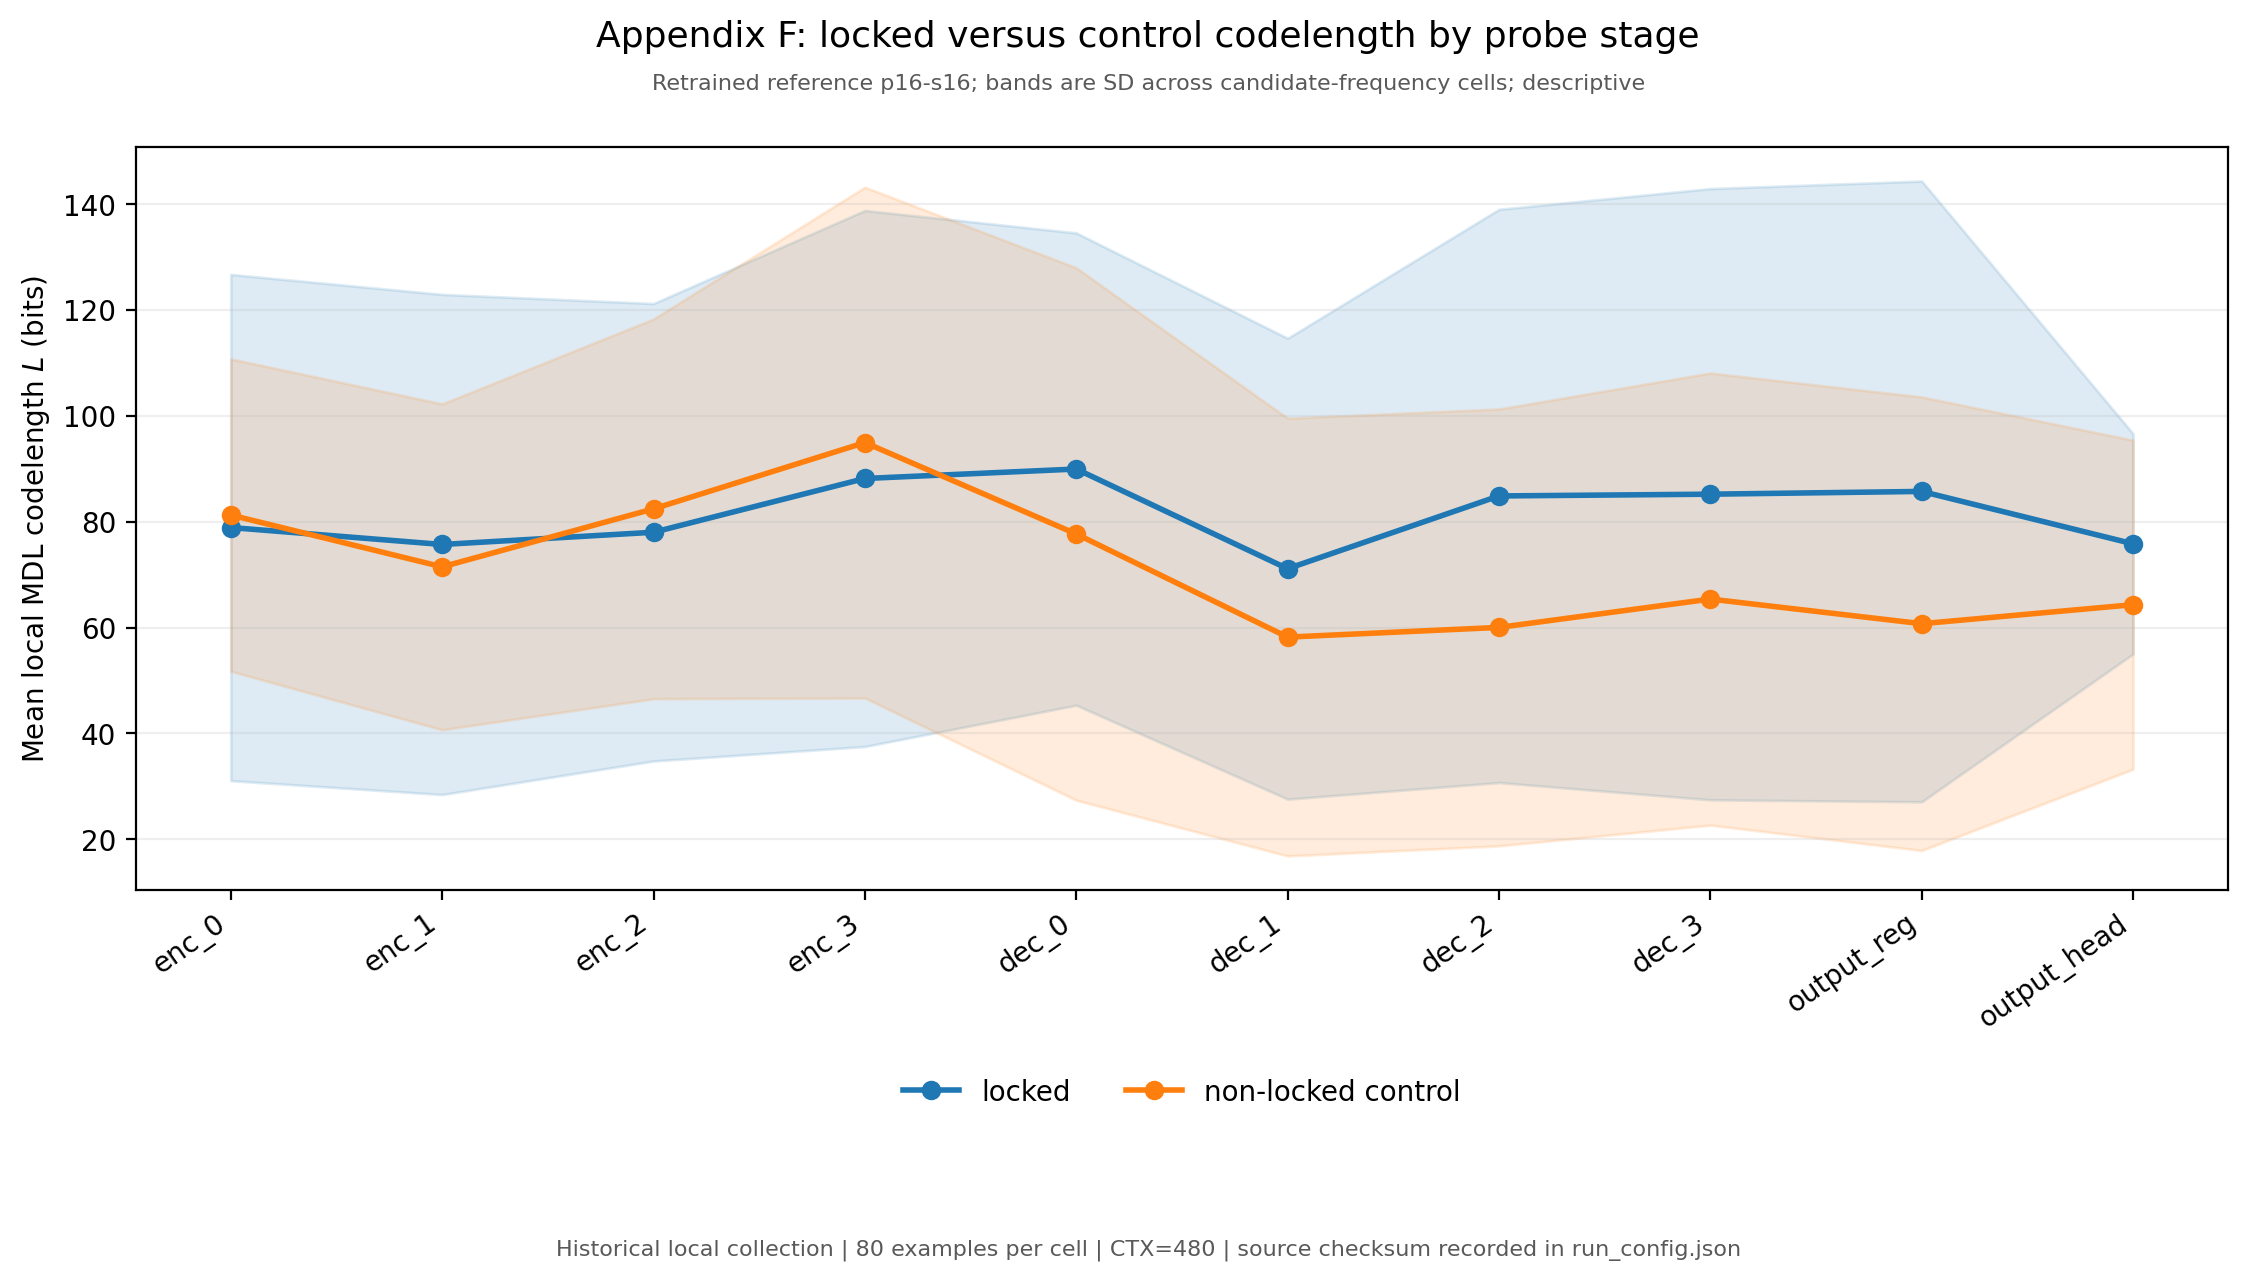

wrote c:\Users\bonio\dev\patchAliasing\chronos\bayesian\_run\probing_space_saving\full\published_p16-s16_20260908T151450185709Z\figures\FIG_APPENDIX_F_gap_bypatch.png (324 kB)
wrote c:\Users\bonio\dev\patchAliasing\chronos\bayesian\_run\probing_space_saving\full\published_p16-s16_20260908T151450185709Z\figures\FIG_APPENDIX_F_gap_bypatch.pdf (28 kB)


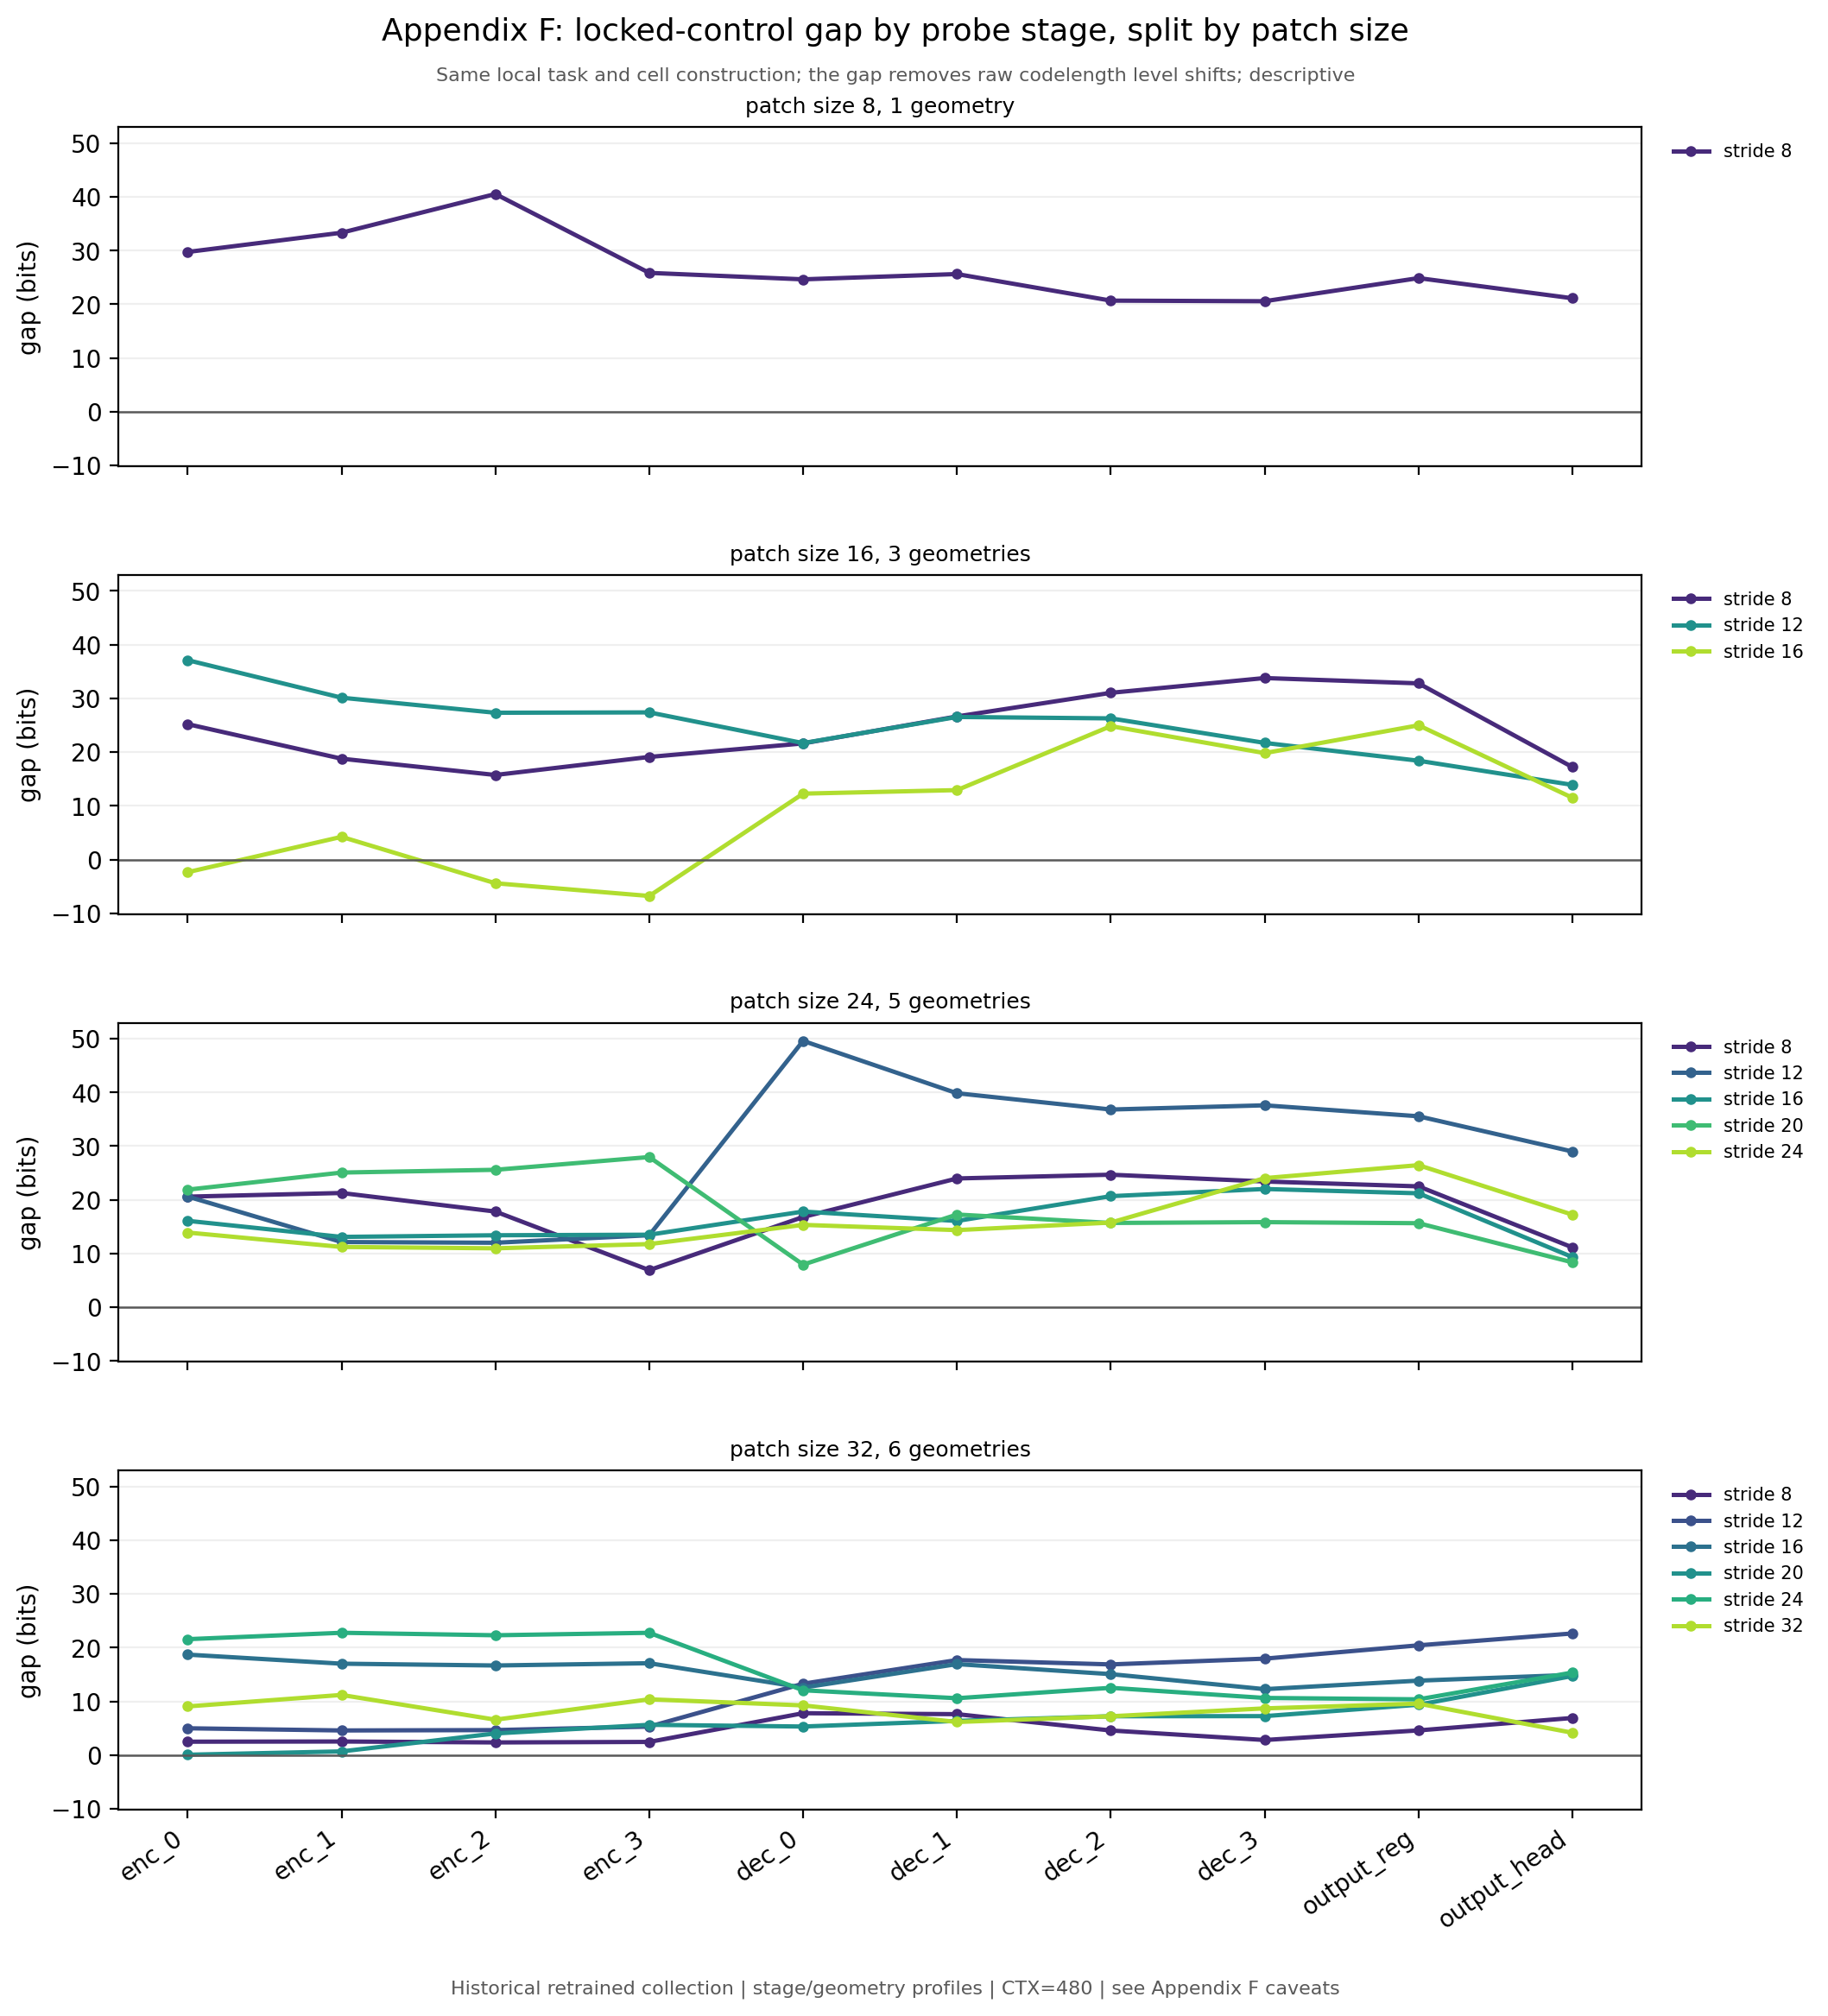

wrote c:\Users\bonio\dev\patchAliasing\chronos\bayesian\_run\probing_space_saving\full\published_p16-s16_20260908T151450185709Z\figures\FIG_APPENDIX_F_gap_bystride.png (360 kB)
wrote c:\Users\bonio\dev\patchAliasing\chronos\bayesian\_run\probing_space_saving\full\published_p16-s16_20260908T151450185709Z\figures\FIG_APPENDIX_F_gap_bystride.pdf (28 kB)


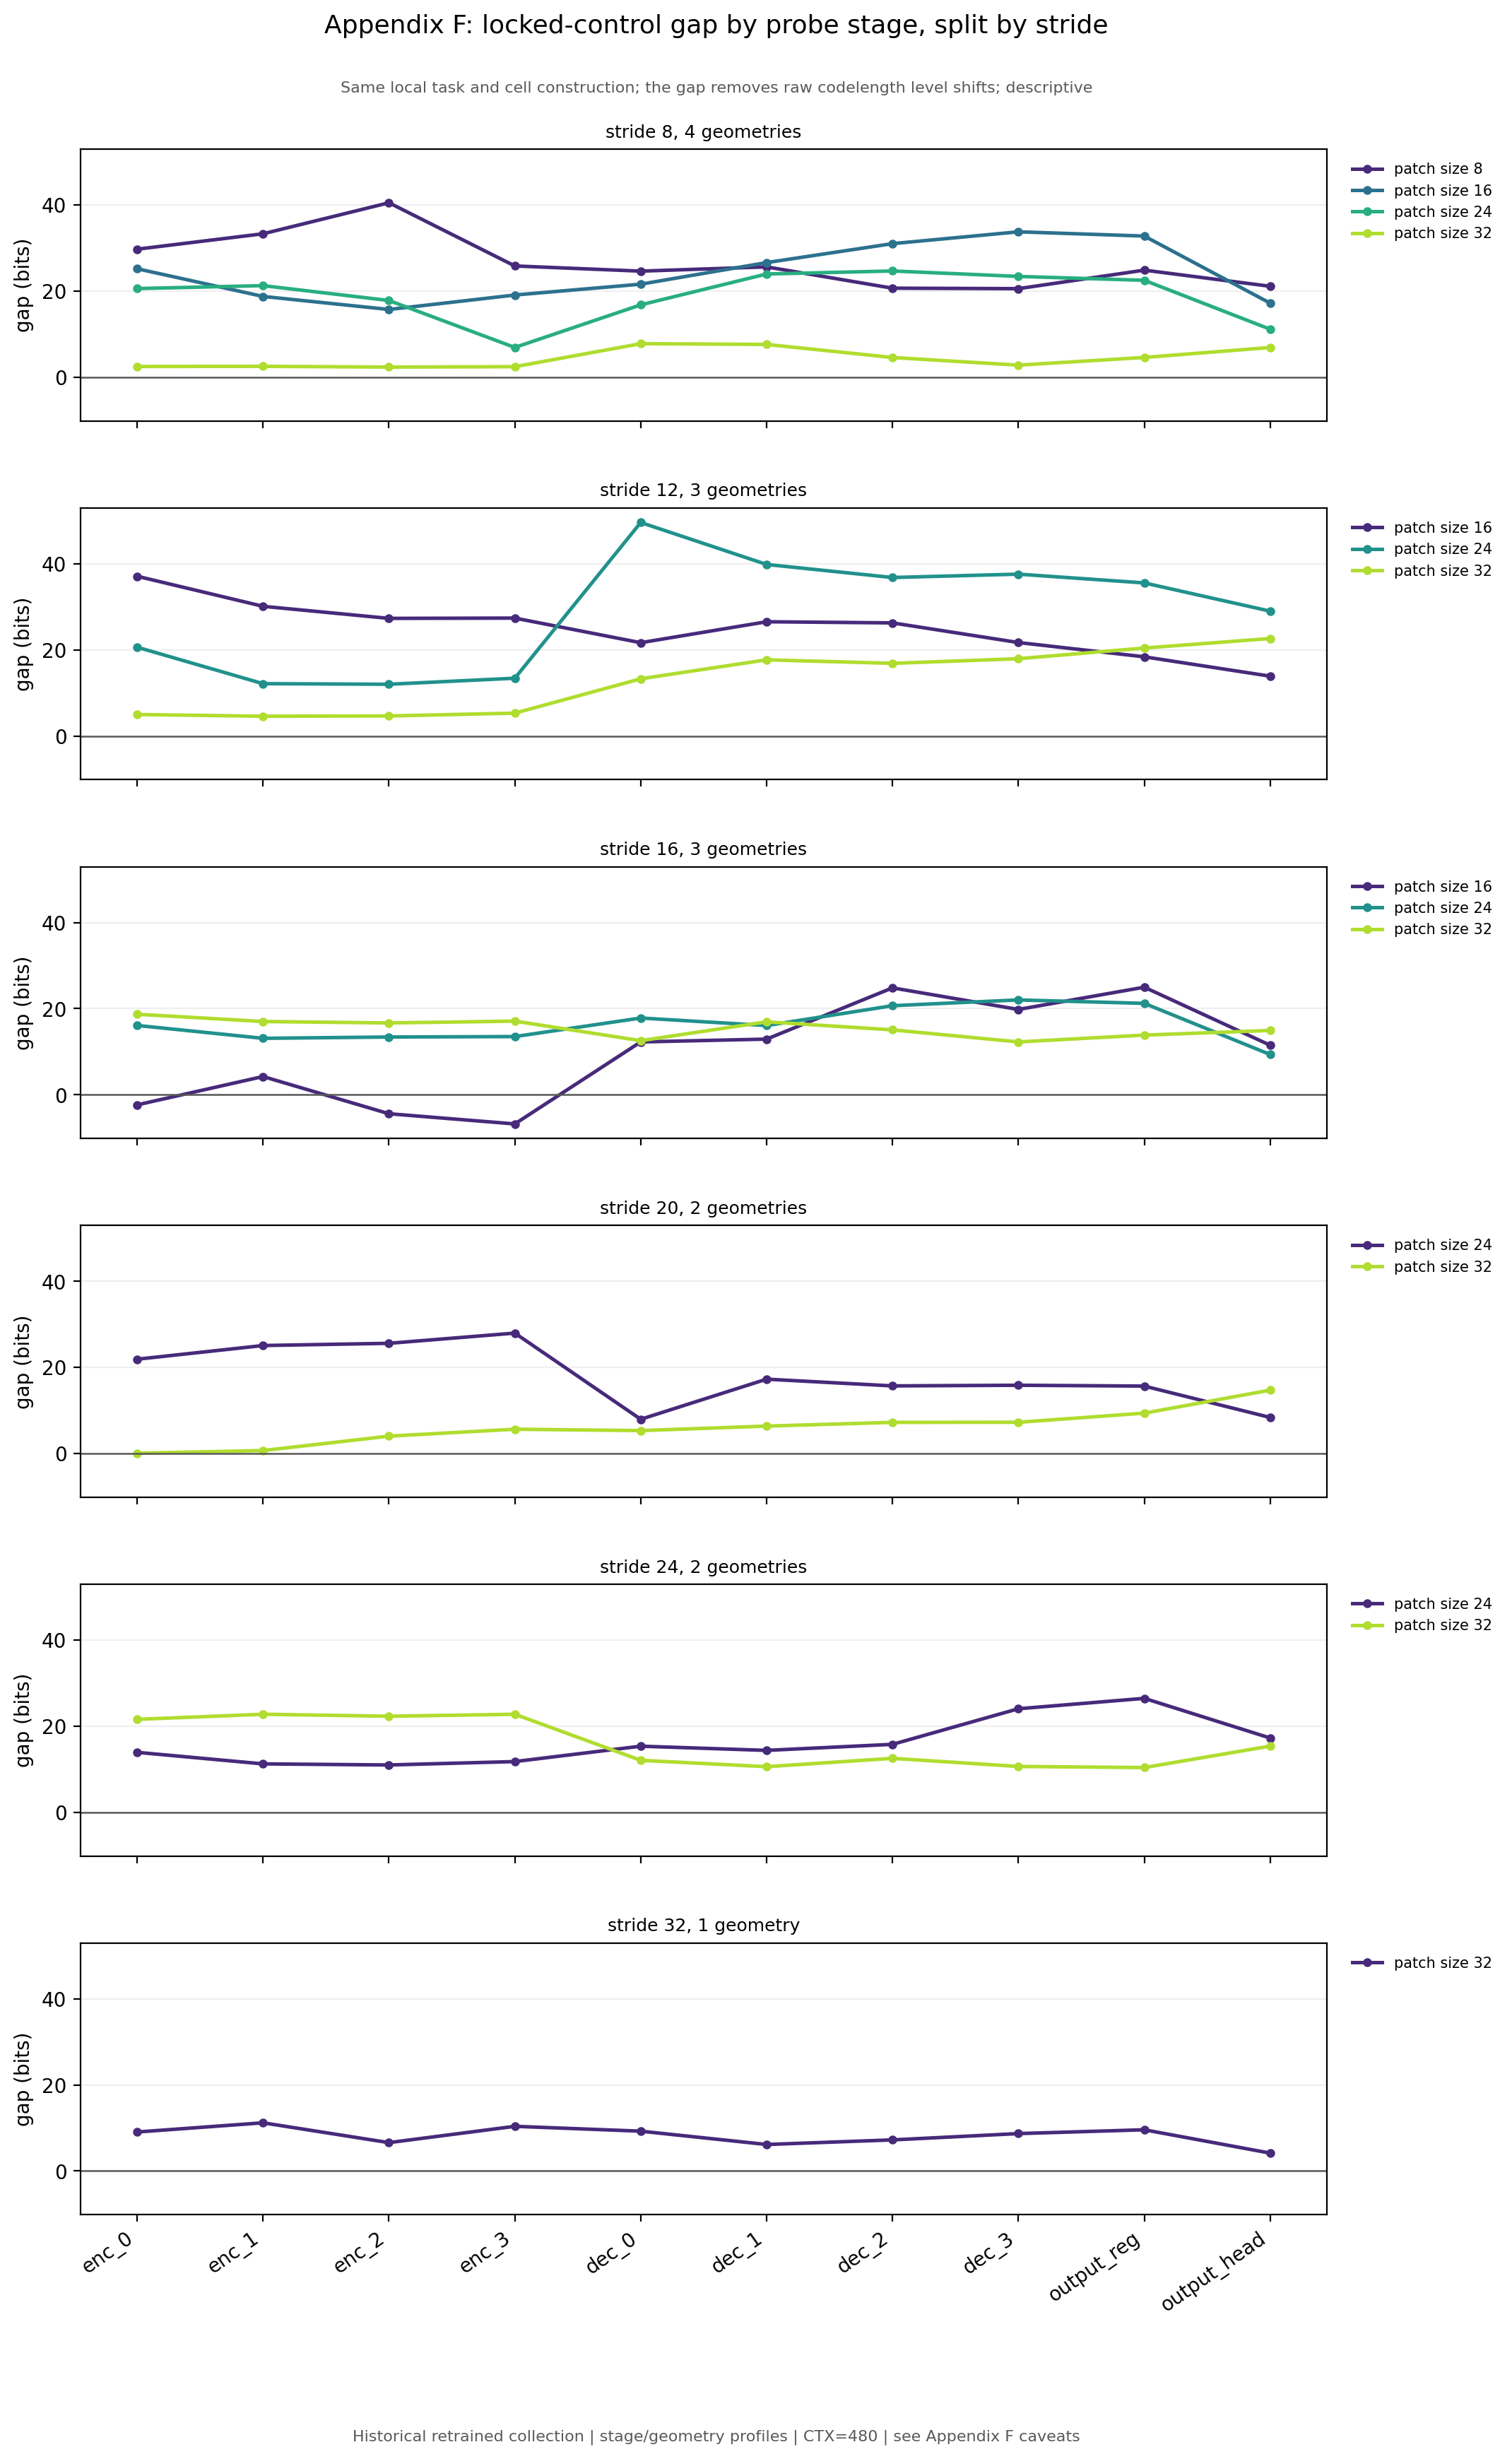

,stage,L_bits_mean_locked,L_bits_mean_control,gap_locked_minus_control,cells,n_per_cell
0,enc_0,78.880,81.238,-2.358,21.0,80.0
1,enc_1,75.683,71.459,4.224,21.0,80.0
2,enc_2,77.990,82.406,-4.417,21.0,80.0
3,enc_3,88.141,94.926,-6.784,21.0,80.0
4,dec_0,89.928,77.664,12.263,21.0,80.0
5,dec_1,71.108,58.191,12.916,21.0,80.0
6,dec_2,84.846,60.023,24.823,21.0,80.0
7,dec_3,85.178,65.374,19.804,21.0,80.0
8,output_reg,85.699,60.720,24.979,21.0,80.0
9,output_head,75.806,64.312,11.494,21.0,80.0


In [41]:
# Load the pinned local MDL-cell collection used by the Appendix F plan.
from urllib.request import Request, urlopen

APPENDIX_F_REFERENCE_GEOMETRY = "p16-s16"
APPENDIX_F_DATA_PATH = None  # Optional local override; the pinned artifact is used when unset.
APPENDIX_F_REVISION = "bba05c84d18983a405a7b4087e2395206a42553e"
APPENDIX_F_RELATIVE_PATH = Path("chronos/bayesian/results/_run_clean_15/data/02_mdl_cells.parquet")
APPENDIX_F_URL = (
    "https://raw.githubusercontent.com/FedericoSabbadini/patchAliasing/"
    f"{APPENDIX_F_REVISION}/{APPENDIX_F_RELATIVE_PATH.as_posix()}"
)
APPENDIX_F_SHA256 = "47799d675c0c4ae9fd94d639fa933825a892c9821f62972928f7e79d97edff61"
APPENDIX_F_STAGES = ([f"enc_{i}" for i in range(4)] + [f"dec_{i}" for i in range(4)]
                     + ["output_reg", "output_head"])


def _find_appendix_f_data():
    if APPENDIX_F_DATA_PATH is not None:
        path = Path(APPENDIX_F_DATA_PATH).expanduser().resolve()
        if not path.is_file():
            raise FileNotFoundError(f"APPENDIX_F_DATA_PATH does not exist: {path}")
        return path, {"kind": "user_override", "path": str(path)}
    for root in (Path.cwd(), *Path.cwd().parents):
        candidate = root / APPENDIX_F_RELATIVE_PATH
        if candidate.is_file():
            return candidate, {"kind": "local_checkout", "path": str(candidate)}
    target = OUT / "inputs" / APPENDIX_F_RELATIVE_PATH.name
    target.parent.mkdir(parents=True, exist_ok=True)
    if not target.is_file() or sha256_file(target) != APPENDIX_F_SHA256:
        request = Request(APPENDIX_F_URL, headers={"User-Agent": "patchAliasing-probing-notebook"})
        with urlopen(request, timeout=120) as response:
            target.write_bytes(response.read())
    if sha256_file(target) != APPENDIX_F_SHA256:
        raise ValueError("Pinned Appendix F artifact checksum mismatch; refusing to plot it.")
    return target, {"kind": "pinned_download", "url": APPENDIX_F_URL,
                    "revision": APPENDIX_F_REVISION, "path": str(target)}


APPENDIX_F_PATH, APPENDIX_F_SOURCE = _find_appendix_f_data()
APPENDIX_F_ACTUAL_SHA256 = sha256_file(APPENDIX_F_PATH)
if APPENDIX_F_SOURCE["kind"] != "user_override" and APPENDIX_F_ACTUAL_SHA256 != APPENDIX_F_SHA256:
    raise ValueError("Local Appendix F artifact differs from the pinned checksum; refusing to plot it.")
APPENDIX_F_PARQUET_ENGINE = None
for candidate in ("pyarrow", "fastparquet"):
    try:
        importlib.import_module(candidate)
    except ImportError:
        continue
    APPENDIX_F_PARQUET_ENGINE = candidate
    break
if APPENDIX_F_PARQUET_ENGINE is None:
    raise ModuleNotFoundError("Appendix F needs a parquet engine. Install pyarrow in the active kernel.")
appendix_cells = pd.read_parquet(APPENDIX_F_PATH, engine=APPENDIX_F_PARQUET_ENGINE)
required_columns = {"model", "P", "S", "stage", "f_center", "is_locked", "n", "L_bits"}
missing_columns = required_columns.difference(appendix_cells.columns)
if missing_columns:
    raise ValueError(f"Appendix F artifact is missing columns: {sorted(missing_columns)}")
appendix_cells["is_locked"] = appendix_cells["is_locked"].astype(int)
if set(appendix_cells["is_locked"].unique()) != {0, 1}:
    raise ValueError("Appendix F must contain both locked and non-locked cells.")
if set(APPENDIX_F_STAGES).difference(appendix_cells["stage"].unique()):
    raise ValueError("Appendix F artifact does not contain all ten probe stages.")
if appendix_cells.duplicated(["model", "P", "S", "stage", "f_center", "is_locked"]).any():
    raise ValueError("Appendix F contains duplicate stage/frequency/lock cells.")
if appendix_cells.groupby(["model", "stage", "is_locked"])["n"].nunique().max() != 1:
    raise ValueError("Appendix F has inconsistent per-cell sample counts.")
reference = appendix_cells[
    (appendix_cells["model"] == APPENDIX_F_REFERENCE_GEOMETRY)
    & (appendix_cells["P"] == 16) & (appendix_cells["S"] == 16)
].copy()
if reference.empty:
    raise ValueError(f"Reference geometry {APPENDIX_F_REFERENCE_GEOMETRY} is absent from Appendix F.")
if set(reference["stage"]) != set(APPENDIX_F_STAGES):
    raise ValueError("Reference geometry is incomplete across the ten probe stages.")

def _profile(frame):
    summary = (frame.groupby(["stage", "is_locked"], as_index=False)
                    .agg(L_bits_mean=("L_bits", "mean"),
                         L_bits_sd=("L_bits", "std"),
                         cells=("L_bits", "size"),
                         n_unique=("n", "nunique"),
                         n_per_cell=("n", "first")))
    if (summary["n_unique"] != 1).any():
        raise ValueError("A stage/lock group mixes different cell sample counts.")
    wide = summary.pivot(index="stage", columns="is_locked", values=["L_bits_mean", "L_bits_sd", "cells", "n_per_cell"])
    wide.columns = [f"{name}_{'locked' if lock else 'control'}" for name, lock in wide.columns]
    wide = wide.reindex(APPENDIX_F_STAGES)
    if (wide["n_per_cell_locked"] != wide["n_per_cell_control"]).any():
        raise ValueError("Locked and control profiles mix different cell sample counts.")
    wide["cells"] = wide["cells_locked"] + wide["cells_control"]
    wide["n_per_cell"] = wide["n_per_cell_locked"]
    wide["gap_locked_minus_control"] = wide["L_bits_mean_locked"] - wide["L_bits_mean_control"]
    wide["stage"] = wide.index
    return wide.reset_index(drop=True)


APPENDIX_F_PROFILE = _profile(reference)
APPENDIX_F_PROFILE.to_csv(OUT / "appendixF_reference_profile.csv", index=False)
geometry_profiles = []
for (geometry, patch_size, stride), group in appendix_cells.groupby(["model", "P", "S"], sort=False):
    geometry_profiles.append(_profile(group).assign(model=geometry, P=patch_size, S=stride))
geometry_profile = pd.concat(geometry_profiles, ignore_index=True)
geometry_profile.to_csv(OUT / "appendixF_geometry_profiles.csv", index=False)

MANIFEST["appendix_f"] = {
    "source": APPENDIX_F_SOURCE,
    "sha256": APPENDIX_F_ACTUAL_SHA256,
    "pinned_url": APPENDIX_F_URL,
    "pinned_revision": APPENDIX_F_REVISION,
    "reference_geometry": APPENDIX_F_REFERENCE_GEOMETRY,
    "stages": APPENDIX_F_STAGES,
    "n_rows": int(len(appendix_cells)),
    "n_geometries": int(appendix_cells[["model", "P", "S"]].drop_duplicates().shape[0]),
    "context_length_in_collection": 480,
    "per_cell_n": sorted(appendix_cells["n"].unique().astype(int).tolist()),
    "interpretation": "descriptive local locked-control codelength; not a hypothesis test",
    "parquet_engine": APPENDIX_F_PARQUET_ENGINE,
}

xs = np.arange(len(APPENDIX_F_STAGES))
NOTE_DEPTH = "Retrained reference p16-s16; bands are SD across candidate-frequency cells; descriptive"
NOTE_GAP = "Same local task and cell construction; the gap removes raw codelength level shifts; descriptive"

fig, ax = plt.subplots(figsize=(13.5, 6.4))
for locked, colour, label in [(1, "tab:blue", "locked"), (0, "tab:orange", "non-locked control")]:
    mean = APPENDIX_F_PROFILE[f"L_bits_mean_{'locked' if locked else 'control'}"].to_numpy(float)
    spread = APPENDIX_F_PROFILE[f"L_bits_sd_{'locked' if locked else 'control'}"].fillna(0).to_numpy(float)
    ax.plot(xs, mean, marker="o", lw=2, color=colour, label=label)
    ax.fill_between(xs, mean - spread, mean + spread, color=colour, alpha=0.14)
ax.set_xticks(xs, APPENDIX_F_STAGES, rotation=35, ha="right")
ax.set_ylabel("Mean local MDL codelength $L$ (bits)")
ax.grid(axis="y", alpha=0.2)
# The note lives above the axes and the legend below them: inside the axes the two collided, and
# the bands leave no corner reliably free.
ax.legend(frameon=False, ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.22))
fig.suptitle("Appendix F: locked versus control codelength by probe stage", fontsize=13, y=0.98)
fig.text(0.5, 0.925, NOTE_DEPTH, ha="center", fontsize=8, color="0.35")
fig.text(0.5, 0.015, "Historical local collection | 80 examples per cell | CTX=480 | source checksum recorded in run_config.json",
         ha="center", fontsize=8, color="0.35")
fig.subplots_adjust(bottom=0.30, top=0.88)
appendix_depth_page = save_figure(fig, "FIG_APPENDIX_F_depth_profile.png")
display(Image(filename=str(appendix_depth_page)))


def gap_page(by, profile=None, fname=None):
    """The locked-control gap, one panel per patch size (by='P') or per stride (by='S').

    Fifteen geometries on one axis are unreadable. Split by patch size the comparison inside a
    panel is across strides, and split by stride it is across patch sizes; the two answer
    different questions and both are drawn.
    """
    prof = geometry_profile if profile is None else profile
    key, other = ("P", "S") if by == "P" else ("S", "P")
    fixed, varying = ("patch size", "stride") if by == "P" else ("stride", "patch size")
    groups = sorted(prof[key].unique())
    n = len(groups)
    fig, axes = plt.subplots(n, 1, figsize=(12.0, 2.9 * n), squeeze=False, sharex=True)
    cmap = plt.get_cmap("viridis")
    lo = float(prof["gap_locked_minus_control"].min())
    hi = float(prof["gap_locked_minus_control"].max())
    pad = 0.06 * (hi - lo)

    for ax, k in zip(axes[:, 0], groups):
        block = prof[prof[key] == k]
        others = sorted(block[other].unique())
        o_lo, o_hi = min(others), max(others)
        for o in others:
            g = block[block[other] == o].set_index("stage").reindex(APPENDIX_F_STAGES)
            frac = 0.0 if o_hi == o_lo else (o - o_lo) / (o_hi - o_lo)
            ax.plot(xs, g["gap_locked_minus_control"].to_numpy(float), marker="o", ms=3.5,
                    lw=1.8, color=cmap(0.12 + 0.76 * frac), label=f"{varying} {o}")
        ax.axhline(0, color="0.35", lw=0.9)
        ax.set_ylim(lo - pad, hi + pad)
        ax.set_ylabel("gap (bits)")
        ax.grid(axis="y", alpha=0.2)
        ax.set_title(f"{fixed} {k}, {len(others)} geometr{'y' if len(others) == 1 else 'ies'}",
                     fontsize=9)
        # outside the axes: inside, a legend lands on the lines whenever a panel is full
        ax.legend(fontsize=7.5, ncol=1, frameon=False, loc="upper left",
                  bbox_to_anchor=(1.01, 1.0))
    axes[-1, 0].set_xticks(xs, APPENDIX_F_STAGES, rotation=35, ha="right")

    fig.suptitle(f"Appendix F: locked-control gap by probe stage, split by {fixed}",
                 fontsize=13, y=0.995)
    fig.text(0.5, 0.963, NOTE_GAP, ha="center", fontsize=8, color="0.35")
    fig.text(0.5, 0.008, "Historical retrained collection | stage/geometry profiles | CTX=480 | see Appendix F caveats",
             ha="center", fontsize=8, color="0.35")
    fig.subplots_adjust(bottom=0.10, top=0.94, right=0.86, hspace=0.32)
    return save_figure(fig, fname or f"FIG_APPENDIX_F_gap_by{'patch' if by == 'P' else 'stride'}.png")


appendix_gap_page = gap_page("P")
display(Image(filename=str(appendix_gap_page)))
appendix_gap_stride_page = gap_page("S")
display(Image(filename=str(appendix_gap_stride_page)))
display(APPENDIX_F_PROFILE[["stage", "L_bits_mean_locked", "L_bits_mean_control",
                           "gap_locked_minus_control", "cells", "n_per_cell"]].round(3))


## 8. Fresh all-stage capture and encoder-only band-task figure

The first fresh figure above deliberately keeps the original decoder-only result. This section
reruns the same real checkpoint and the same pure-sinusoid band-task MDL with all ten probe points,
including the encoder `[REG]` vector after each encoder block and the pre-projection vector. The
encoder figure below uses exactly the current grouped-bar style, including the red dashed
`max(SV)` of the displayed encoder grid, with the derived estimator ceiling reported in the caption. The
three-decimal shuffled-label controls and `Δ` distances are aligned just after that line. It is produced
from model predictions, not from the Appendix F collection.


In [42]:
# Recapture the same contexts with all ten probe stages, including encoder [REG] states.
PIPE, MODEL_CONFIG, CHECKPOINT = load_model()
PREDICTION_LENGTH = int(MODEL_CONFIG["prediction_length"])
MEDIAN_INDEX = list(MODEL_CONFIG["quantiles"]).index(0.5)
ALL_STAGES = ([f"enc_{i}" for i in range(len(PIPE.model.encoder.block))]
              + [f"dec_{i}" for i in range(len(PIPE.model.decoder.block))]
              + ["output_reg", "output_head"])
ENCODER_STAGES = [s for s in ALL_STAGES if s.startswith("enc_")]


def forecast_and_capture_all(pipe, contexts, batch_size, device, median_index, prediction_length):
    model = pipe.model
    stages = ALL_STAGES
    captured, pieces, predictions = {}, {s: [] for s in stages}, []
    handles = []

    def capture(stage, position):
        def hook(_module, _args, output):
            value = output[0] if isinstance(output, tuple) else output
            if value.ndim == 3:
                if position == "last":
                    value = value[:, -1, :]
                else:
                    value = value[:, 0, :]
            if value.ndim != 2:
                raise ValueError(f"{stage}: unexpected shape {tuple(value.shape)}")
            captured[stage] = value.detach().float().cpu().numpy().copy()
        return hook

    def capture_input(stage):
        def hook(_module, args, _output):
            value = args[0]
            if value.ndim == 3:
                value = value[:, 0, :]
            if value.ndim != 2:
                raise ValueError(f"{stage}: unexpected input shape {tuple(value.shape)}")
            captured[stage] = value.detach().float().cpu().numpy().copy()
        return hook

    try:
        for i, block in enumerate(model.encoder.block):
            handles.append(block.register_forward_hook(capture(f"enc_{i}", "last")))
        for i, block in enumerate(model.decoder.block):
            handles.append(block.register_forward_hook(capture(f"dec_{i}", "first")))
        handles.append(model.output_patch_embedding.register_forward_hook(capture_input("output_reg")))
        handles.append(model.output_patch_embedding.register_forward_hook(capture("output_head", "first")))
        with torch.inference_mode():
            for start in tqdm(range(0, len(contexts), batch_size), desc="All-stage predictions + states"):
                captured.clear()
                xb = torch.as_tensor(contexts[start:start + batch_size], dtype=torch.float32, device=device)
                forecasts = pipe.predict(xb, prediction_length=prediction_length)
                if forecasts.ndim != 3 or forecasts.shape[0] != len(xb) or forecasts.shape[-1] != prediction_length:
                    raise ValueError(f"Unexpected forecast shape: {tuple(forecasts.shape)}")
                predictions.append(forecasts[:, median_index, :].detach().float().cpu().numpy())
                for stage in stages:
                    if stage not in captured or captured[stage].shape[0] != len(xb):
                        raise RuntimeError(f"Missing or misaligned captured features at {stage}")
                    pieces[stage].append(captured[stage])
    finally:
        for handle in handles:
            handle.remove()
    features = {stage: np.concatenate(values) for stage, values in pieces.items()}
    prediction = np.concatenate(predictions)
    if not np.isfinite(prediction).all() or any(not np.isfinite(x).all() for x in features.values()):
        raise ValueError("Non-finite predictions or features; all-stage MDL was not started.")
    return prediction, features


started = time.monotonic()
PREDICTIONS_ALL, FEATURES_ALL = forecast_and_capture_all(
    PIPE, CONTEXTS, BATCH_SIZE, DEVICE, MEDIAN_INDEX, PREDICTION_LENGTH)
np.savez_compressed(OUT / "predictions_and_states_all_stages.npz", predictions=PREDICTIONS_ALL,
                    true_futures=TRUE_FUTURES, frequency_hz=FREQUENCIES, shift_samples=SHIFTS,
                    **FEATURES_ALL)
MANIFEST["all_stage_feature_shapes"] = {s: list(x.shape) for s, x in FEATURES_ALL.items()}
MANIFEST["all_stage_inference_seconds"] = time.monotonic() - started
MANIFEST["all_stages"] = ALL_STAGES
MANIFEST["status"] = "all_stage_mdl_pending"
(OUT / "run_config.json").write_text(json.dumps(MANIFEST, indent=2) + "\n", encoding="utf-8")
print("All-stage forecasts:", PREDICTIONS_ALL.shape, "features:", MANIFEST["all_stage_feature_shapes"])
del PIPE
if torch.cuda.is_available():
    torch.cuda.empty_cache()


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

All-stage predictions + states:   0%|          | 0/123 [00:00<?, ?it/s]

All-stage forecasts: (7813, 64) features: {'enc_0': [7813, 256], 'enc_1': [7813, 256], 'enc_2': [7813, 256], 'enc_3': [7813, 256], 'dec_0': [7813, 256], 'dec_1': [7813, 256], 'dec_2': [7813, 256], 'dec_3': [7813, 256], 'output_reg': [7813, 256], 'output_head': [7813, 576]}


## 9. Fresh all-stage MDL

This is the same prequential estimator as the decoder-only table: one fixed sample permutation per
task, scaling and PCA fitted inside each training prefix, logistic probes for true and shuffled labels,
and a uniform first chunk. All ten stages are checked before the encoder plot is drawn.


In [43]:
def run_mdl_all(features, frequencies):
    rows, coding_rows = [], []
    total = len(BAND_TASKS) * len(ALL_STAGES)
    with threadpool_limits(limits=CPU_THREADS):
        with tqdm(total=total, desc="All-stage MDL task/stage pairs") as progress:
            for task_index, (name, lo, hi, boundary) in enumerate(BAND_TASKS):
                mask = (frequencies >= lo) & (frequencies <= hi)
                y = (frequencies[mask] > boundary).astype(int)
                shuffled = np.random.default_rng(SEED + task_index).permutation(y)
                for stage in ALL_STAGES:
                    bits, control_bits, audit = mdl_pair(features[stage][mask], y, shuffled,
                                                         MDL_CHUNKS, PCA_COMPONENTS, SEED)
                    n = len(y)
                    rows.append(dict(model=GEOMETRY, model_source=MODEL_SOURCE, P=P, S=S, stage=stage, task=name,
                                     n=n, n_class0=int((y == 0).sum()), n_class1=int((y == 1).sum()),
                                     L_bits=bits, L_uniform=float(n), L_shuffled_bits=control_bits,
                                     SV=1 - bits/n, SV_shuffled=1 - control_bits/n,
                                     SV_ceiling=1 - audit[0]["n_test"]/n))
                    coding_rows.extend(dict(model=GEOMETRY, model_source=MODEL_SOURCE, stage=stage,
                                             task=name, **r) for r in audit)
                    pd.DataFrame(rows).to_csv(OUT / "space_saving_all_stages_partial.csv", index=False)
                    progress.update(1)
    return pd.DataFrame(rows), pd.DataFrame(coding_rows)


started = time.monotonic()
BT_ALL, CODING_ALL = run_mdl_all(FEATURES_ALL, FREQUENCIES)
if BT_ALL.duplicated(["model", "stage", "task"]).any() or len(BT_ALL) != len(BAND_TASKS) * len(ALL_STAGES):
    raise RuntimeError("Incomplete or duplicated all-stage MDL results.")
np.testing.assert_allclose(BT_ALL["SV"], 1 - BT_ALL["L_bits"] / BT_ALL["n"])
if (BT_ALL["SV"] > BT_ALL["SV_ceiling"] + 1e-9).any():
    raise RuntimeError("All-stage SV exceeds the prequential first-chunk ceiling.")
BT_ALL.to_csv(OUT / "02_mdl_bandtasks_all_stages.csv", index=False)
CODING_ALL.to_csv(OUT / "mdl_coding_chunks_all_stages.csv", index=False)
MANIFEST["all_stage_mdl_seconds"] = time.monotonic() - started
MANIFEST["status"] = "all_stage_mdl_complete"
(OUT / "run_config.json").write_text(json.dumps(MANIFEST, indent=2) + "\n", encoding="utf-8")
chunk_totals = CODING_ALL.groupby(["stage", "task"])[["bits_true", "bits_shuffled"]].sum().sort_index()
by_pair = BT_ALL.set_index(["stage", "task"]).sort_index()
np.testing.assert_allclose(chunk_totals["bits_true"], by_pair["L_bits"])
np.testing.assert_allclose(chunk_totals["bits_shuffled"], by_pair["L_shuffled_bits"])
print(f"All-stage true-label SV: {BT_ALL.SV.min():.6f} to {BT_ALL.SV.max():.6f}")
print(f"All-stage shuffled-label SV: {BT_ALL.SV_shuffled.min():.6f} to {BT_ALL.SV_shuffled.max():.6f}")


All-stage MDL task/stage pairs:   0%|          | 0/70 [00:00<?, ?it/s]

All-stage true-label SV: 0.335923 to 0.798509
All-stage shuffled-label SV: -0.032184 to -0.002733


## 10. Encoder-only figure from fresh model predictions

This repeats the grouped bars used for the decoder figure but restricts the y-axis to the four
encoder blocks. Bars are true-label space saving; parentheses are the independent shuffled-label
control. The red dashed line is the largest `SV` among the displayed encoder tasks, and the derived estimator ceiling
`1 - ceil(n/5)/n`, the most any probe could save here, is reported in the caption rather than drawn
across the labels. Each label reports `Δ`, the distance from its bar to that maximum,
and all labels are placed immediately after the red line.


wrote c:\Users\bonio\dev\patchAliasing\chronos\bayesian\_run\probing_space_saving\full\published_p16-s16_20260908T151450185709Z\figures\FIG_SV_published_p16-s16_encoders.png (175 kB)
wrote c:\Users\bonio\dev\patchAliasing\chronos\bayesian\_run\probing_space_saving\full\published_p16-s16_20260908T151450185709Z\figures\FIG_SV_published_p16-s16_encoders.pdf (27 kB)


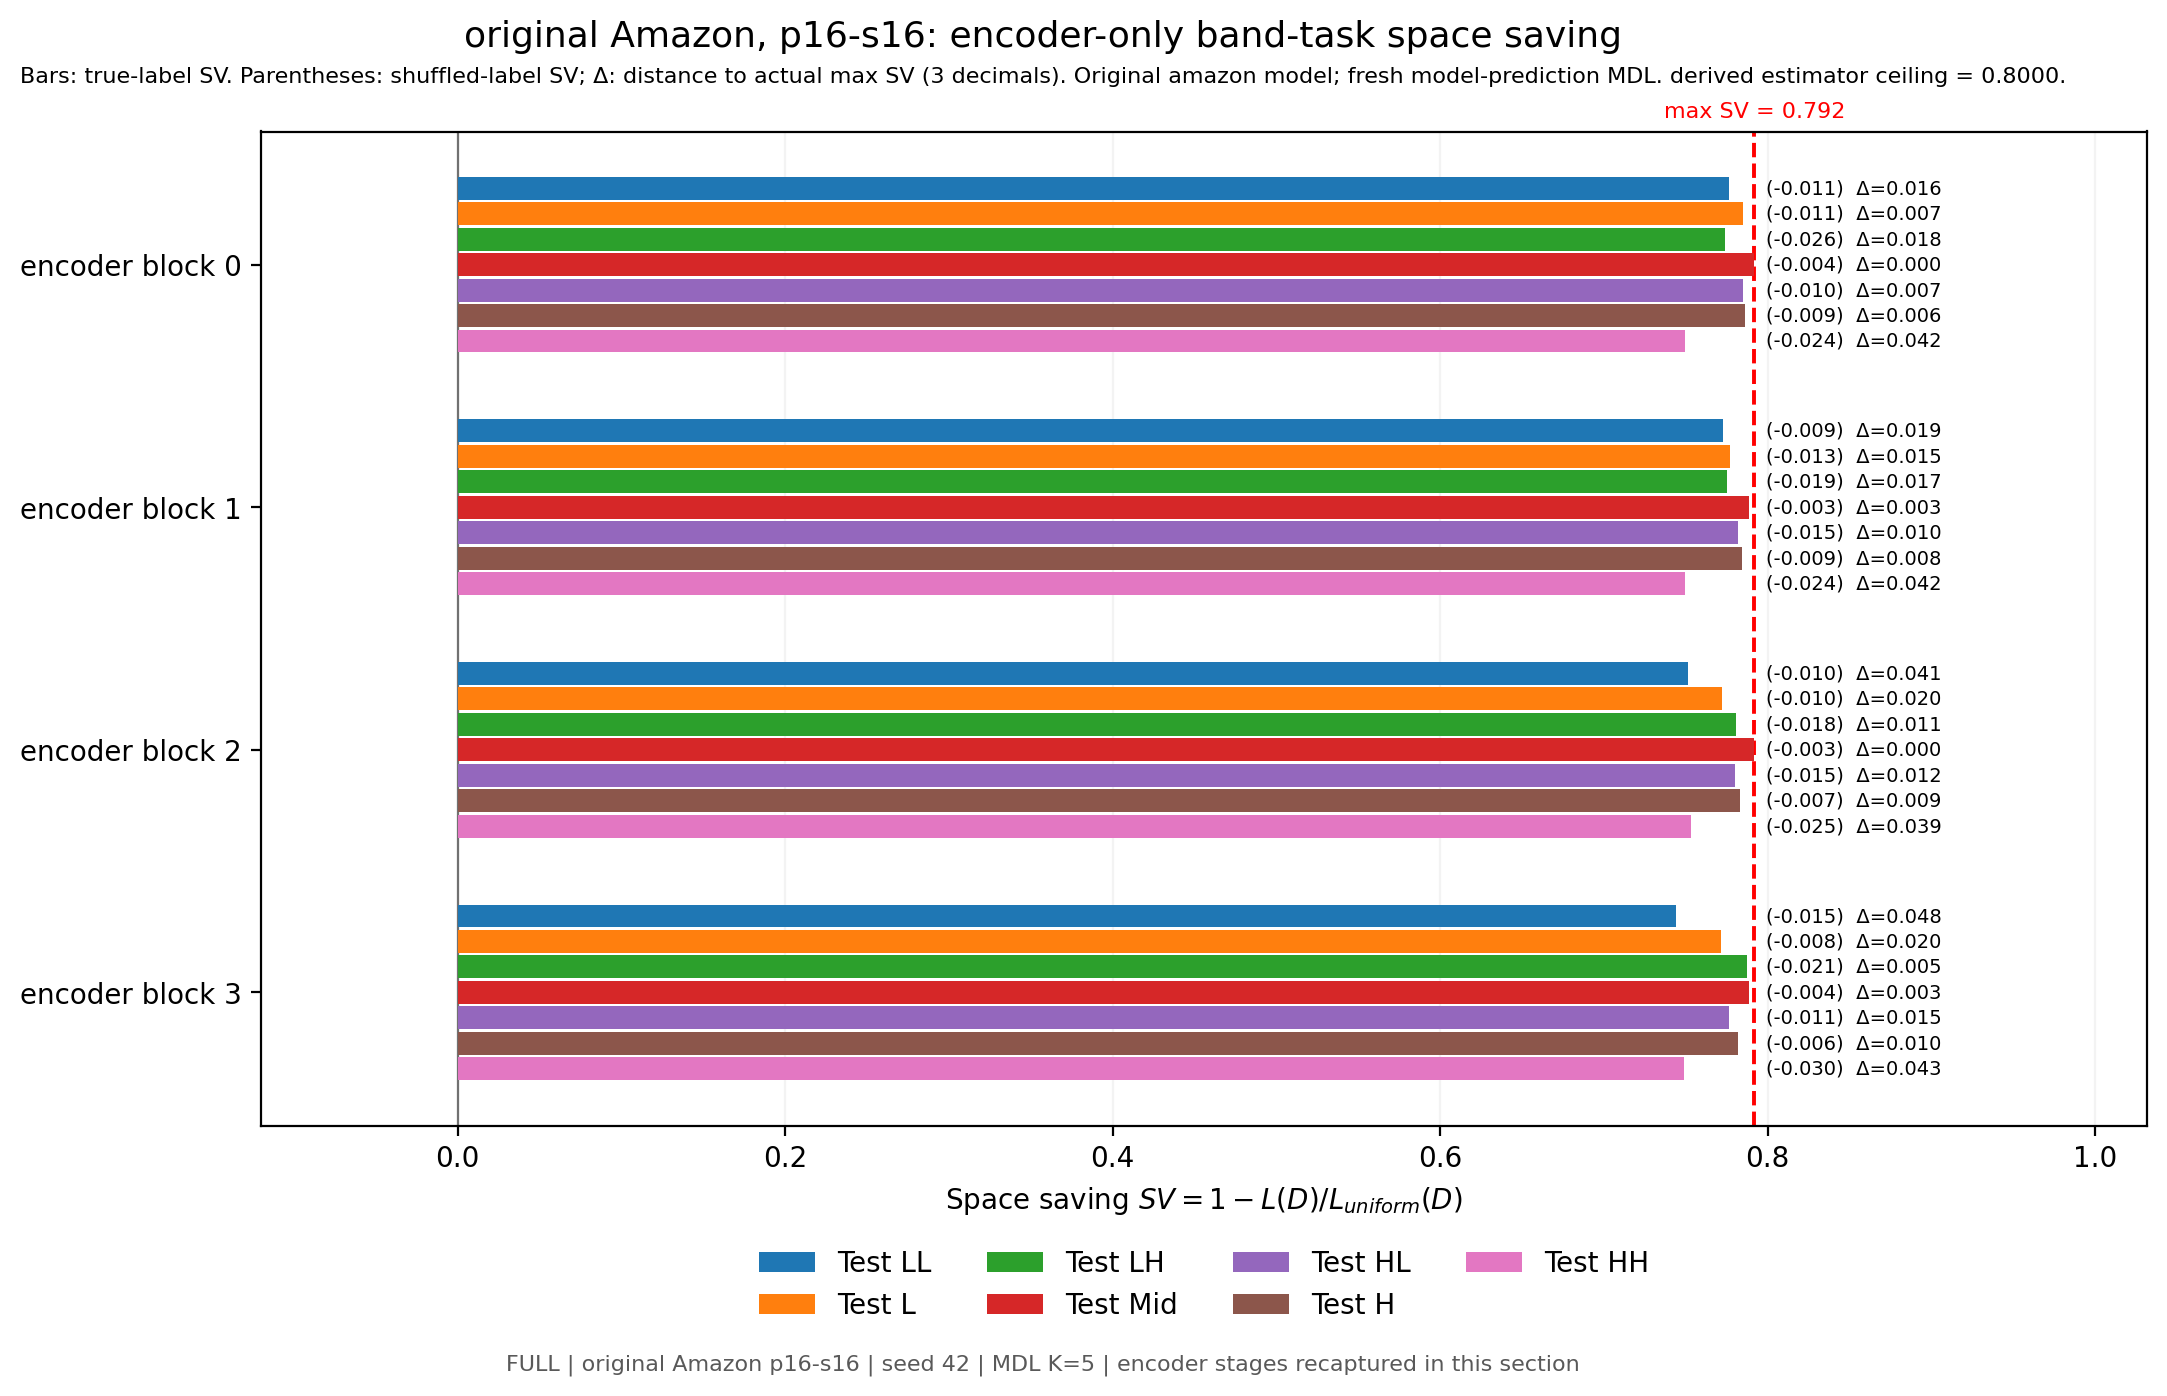

In [44]:
def encoder_spacesaving_page(table=BT_ALL, geometry=GEOMETRY, fname=None):
    d = table[table["model"] == geometry]
    if d.empty:
        raise ValueError(f"{geometry} not in the all-stage table; available: {sorted(table['model'].unique())}")
    grid = complete_grid(d, ["stage", "task"], [ENCODER_STAGES, TASK_ORDER])
    max_sv = round(float(grid["SV"].max()), 3)
    if not np.isfinite(max_sv) or not (0 <= max_sv <= 1):
        raise ValueError(f"Invalid computed maximum SV: {max_sv}")
    colours = plt.get_cmap("tab10").colors[:len(TASK_ORDER)]
    fig, ax = plt.subplots(figsize=(11.5, 7.0))
    height = 0.105
    ys = np.arange(len(ENCODER_STAGES))
    for i, (task, colour) in enumerate(zip(TASK_ORDER, colours)):
        sub = grid.xs(task, level="task").reindex(ENCODER_STAGES)
        pos = ys + (i - (len(TASK_ORDER) - 1) / 2) * height
        ax.barh(pos, sub["SV"], height=height * 0.9, color=colour, label=f"Test {task}")
        for y, (_, row) in zip(pos, sub.iterrows()):
            control = row.get("SV_shuffled", np.nan)
            distance = max(0.0, max_sv - float(row["SV"]))
            text = (f"({control:+.3f})  Δ={distance:.3f}" if pd.notna(control)
                    else f"(n/a)  Δ={distance:.3f}")
            ax.annotate(text, (max_sv, y), xytext=(4, 0),
                        textcoords="offset points", ha="left",
                        va="center", fontsize=7)
    values = grid["SV"].to_numpy()
    ax.set_xlim(min(0, values.min()) - 0.12, max_sv + 0.24)
    ax.axvline(0, color="0.4", lw=0.8, zorder=0)
    ax.axvline(max_sv, color="red", ls="--", lw=1.4, zorder=0)
    ceiling, ceiling_is_clear = ceiling_note(grid, max_sv)
    if ceiling is not None and ceiling_is_clear:
        ax.set_xlim(right=max(ax.get_xlim()[1], ceiling[1] + 0.24))
        ax.axvline(ceiling[1], color="tab:green", ls=":", lw=1.4, zorder=0)
        ax.text(ceiling[1], -0.055, ceiling[2], transform=ax.get_xaxis_transform(),
                color="tab:green", ha="center", va="top", fontsize=8, clip_on=False)
    ax.text(max_sv, 1.01, f"max SV = {max_sv:.3f}", transform=ax.get_xaxis_transform(),
            color="red", ha="center", va="bottom", fontsize=8, clip_on=False)
    ax.set_yticks(ys, [nice(s) for s in ENCODER_STAGES])
    ax.invert_yaxis()
    ax.set_xlabel(r"Space saving $SV = 1 - L(D)/L_{uniform}(D)$")
    ax.grid(axis="x", alpha=0.15); ax.set_axisbelow(True)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.10), ncol=4, frameon=False)
    fig.suptitle(f"{MODEL_LABEL}, {geometry}: encoder-only band-task space saving", fontsize=13, y=0.98)
    caption = ("Bars: true-label SV. Parentheses: shuffled-label SV; Δ: distance to actual max SV "
               "(3 decimals). "
               f"{MODEL_LABEL.capitalize()} model; fresh model-prediction MDL.")
    if ceiling is not None and not ceiling_is_clear:
        caption += f" {ceiling[2]}."
    fig.text(0.5, 0.935, caption, ha="center", fontsize=8)
    fig.text(0.5, 0.015, SOURCE_NOTE + " | encoder stages recaptured in this section", ha="center", fontsize=8, color="0.35")
    fig.subplots_adjust(left=0.16, right=0.98, top=0.90, bottom=0.19)
    return save_figure(fig, fname or f"FIG_SV_{MODEL_SOURCE}_{geometry}_encoders.png")


encoder_page = encoder_spacesaving_page()
display(Image(filename=str(encoder_page)))


## 11. Saved results

The CSV files and figures are outputs of the fresh model/MDL run and the descriptive Appendix F
profile. The fresh run remains the source for the seven band-task figures; the Appendix F artifact
is recorded with its URL or local path and checksum.


In [45]:
piv_all = BT_ALL.pivot(index="stage", columns="task", values="SV").reindex(index=ALL_STAGES, columns=TASK_ORDER)
piv_all.to_csv(OUT / "space_saving_all_stages.csv")
MANIFEST["status"] = "complete"
MANIFEST["figures"] = {
    "decoder_band_tasks": str(page),
    "encoder_band_tasks": str(encoder_page),
    "appendix_f_depth": str(appendix_depth_page),
    "appendix_f_geometry_gap": str(appendix_gap_page),
}
(OUT / "run_config.json").write_text(json.dumps(MANIFEST, indent=2) + "\n", encoding="utf-8")
display(piv_all.round(3))
print("Finished:", OUT)
for file in sorted(OUT.rglob("*")):
    if file.is_file():
        print(f"  {file.relative_to(OUT)} ({file.stat().st_size / 1024:.0f} kB)")


task,LL,L,LH,Mid,HL,H,HH
stage,,,,,,,
enc_0,0.776,0.785,0.774,0.792,0.785,0.786,0.750
enc_1,0.773,0.777,0.775,0.789,0.782,0.784,0.750
enc_2,0.751,0.772,0.781,0.792,0.780,0.783,0.753
enc_3,0.744,0.772,0.787,0.789,0.777,0.782,0.749
dec_0,0.790,0.799,0.798,0.795,0.777,0.791,0.793
dec_1,0.785,0.796,0.794,0.794,0.775,0.789,0.790
dec_2,0.767,0.794,0.791,0.788,0.782,0.784,0.782
dec_3,0.751,0.779,0.792,0.765,0.786,0.775,0.786
output_reg,0.782,0.786,0.791,0.753,0.785,0.780,0.786


Finished: c:\Users\bonio\dev\patchAliasing\chronos\bayesian\_run\probing_space_saving\full\published_p16-s16_20260908T151450185709Z
  02_mdl_bandtasks.csv (5 kB)
  02_mdl_bandtasks_all_stages.csv (10 kB)
  appendixF_geometry_profiles.csv (21 kB)
  appendixF_reference_profile.csv (1 kB)
  figures\FIG_APPENDIX_F_depth_profile.pdf (22 kB)
  figures\FIG_APPENDIX_F_depth_profile.png (197 kB)
  figures\FIG_APPENDIX_F_gap_bypatch.pdf (28 kB)
  figures\FIG_APPENDIX_F_gap_bypatch.png (324 kB)
  figures\FIG_APPENDIX_F_gap_bystride.pdf (28 kB)
  figures\FIG_APPENDIX_F_gap_bystride.png (360 kB)
  figures\FIG_SV_published_p16-s16.pdf (28 kB)
  figures\FIG_SV_published_p16-s16.png (200 kB)
  figures\FIG_SV_published_p16-s16_encoders.pdf (27 kB)
  figures\FIG_SV_published_p16-s16_encoders.png (175 kB)
  mdl_coding_chunks.csv (12 kB)
  mdl_coding_chunks_all_stages.csv (24 kB)
  predictions_and_states.npz (47030 kB)
  predictions_and_states_all_stages.npz (83517 kB)
  run_config.json (5 kB)
  space_sav

## 12. Appendix F table, ready to include

The per-stage table the Appendix F plan asks for, written as a LaTeX tabular so it can be included
in the report without retyping. One row per probe stage: mean codelength at candidate frequencies,
mean at their controls, the difference, the number of cells behind each mean and the examples per
cell. It is the checkable companion to the two profile figures.

In [46]:
def write_appendix_f_table(profile=None, fname="appendixF_reference_profile.tex"):
    prof = APPENDIX_F_PROFILE if profile is None else profile
    path = OUT / fname
    lines = [r"\begin{tabular}{@{}lrrrrr@{}}", r"\toprule",
             r"Probe stage & $L$ candidates & $L$ controls & gap & cells & per cell \\",
             r"\midrule"]
    for _, r in prof.iterrows():
        lines.append(f"{r['stage'].replace('_', chr(92)+'_')} & "
                     f"{r['L_bits_mean_locked']:.1f} & {r['L_bits_mean_control']:.1f} & "
                     f"{r['gap_locked_minus_control']:+.1f} & {int(r['cells'])} & "
                     f"{int(r['n_per_cell'])} \\\\")
    lines += [r"\bottomrule", r"\end{tabular}"]
    path.write_text("\n".join(lines) + "\n", encoding="utf-8")
    report(path)
    return path


appendix_table_path = write_appendix_f_table()
print(APPENDIX_F_PROFILE[["stage", "L_bits_mean_locked", "L_bits_mean_control",
                          "gap_locked_minus_control", "cells", "n_per_cell"]].round(2).to_string(index=False))


wrote c:\Users\bonio\dev\patchAliasing\chronos\bayesian\_run\probing_space_saving\full\published_p16-s16_20260908T151450185709Z\appendixF_reference_profile.tex (1 kB)
      stage  L_bits_mean_locked  L_bits_mean_control  gap_locked_minus_control  cells  n_per_cell
      enc_0               78.88                81.24                     -2.36   21.0        80.0
      enc_1               75.68                71.46                      4.22   21.0        80.0
      enc_2               77.99                82.41                     -4.42   21.0        80.0
      enc_3               88.14                94.93                     -6.78   21.0        80.0
      dec_0               89.93                77.66                     12.26   21.0        80.0
      dec_1               71.11                58.19                     12.92   21.0        80.0
      dec_2               84.85                60.02                     24.82   21.0        80.0
      dec_3               85.18                65

## 13. Both checkpoints in one run

`MODEL_SOURCE` selects the checkpoint the sections above report, and the comparison the deliverable
wants is between the two. This section completes it inside the same run instead of asking for a
second one: the table already computed for `MODEL_SOURCE` is reused, and only the other checkpoint
is loaded and measured. The inputs, seeds, probe stages, chunking and estimator are the ones defined
at the top of the notebook and are untouched, so the checkpoint is the only thing that differs
between the two readings.

Cost is one extra model load, one extra inference pass over the same contexts, and one extra
all-stage MDL. The captured states of each checkpoint are released as soon as its table is complete,
so only one set is held at a time.

In [47]:
PAIR_SOURCES = ("retrained", "published")     # both are measured; order fixes the figure only
if MODEL_SOURCE not in PAIR_SOURCES:
    raise ValueError(f"MODEL_SOURCE {MODEL_SOURCE!r} is not one of {PAIR_SOURCES}")


def measure_source(source):
    """Load `source`, capture the ten probe stages on the same contexts, and run the all-stage MDL.

    The published checkpoint exists only at (16, 16); a request for it at another geometry is an
    error rather than a silent substitution.
    """
    global MODEL_SOURCE, MODEL_LABEL
    if source == "published" and (P, S) != (16, 16):
        raise ValueError("The original Chronos-Bolt-Tiny has P=S=16; it cannot be paired here.")
    keep = (MODEL_SOURCE, MODEL_LABEL)
    try:
        MODEL_SOURCE = source
        MODEL_LABEL = "original Amazon" if source == "published" else "retrained"
        pipe, config, checkpoint = load_model()
        stages = ([f"enc_{i}" for i in range(len(pipe.model.encoder.block))]
                  + [f"dec_{i}" for i in range(len(pipe.model.decoder.block))]
                  + ["output_reg", "output_head"])
        if stages != ALL_STAGES:
            raise ValueError(f"{source} exposes {stages}, not the ten stages measured above")
        median_index = list(config["quantiles"]).index(0.5)
        # forecast_and_capture_all returns (predictions, features); the guard keeps a change in
        # that order from becoming a confusing IndexError inside the MDL loop.
        _, features = forecast_and_capture_all(pipe, CONTEXTS, BATCH_SIZE, DEVICE,
                                               median_index, int(config["prediction_length"]))
        if not isinstance(features, dict) or set(features) != set(ALL_STAGES):
            raise TypeError("expected a {stage: features} mapping over the ten probe stages")
        table, _ = run_mdl_all(features, FREQUENCIES)
        del features, pipe
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        return table, checkpoint
    finally:
        MODEL_SOURCE, MODEL_LABEL = keep


TABLES = {MODEL_SOURCE: BT_ALL}               # the source this run already measured
CHECKPOINTS = {MODEL_SOURCE: CHECKPOINT}
for src in PAIR_SOURCES:
    if src in TABLES:
        print(f"{src}: already measured in this run")
        continue
    print(f"{src}: measuring")
    TABLES[src], CHECKPOINTS[src] = measure_source(src)

for src, table in TABLES.items():
    if len(table) != len(BAND_TASKS) * len(ALL_STAGES) or table.duplicated(["stage", "task"]).any():
        raise RuntimeError(f"{src}: incomplete or duplicated all-stage MDL results.")
    table.to_csv(OUT / f"02_mdl_bandtasks_all_stages_{src}.csv", index=False)
    print(f"{src}: SV {table.SV.min():.4f} to {table.SV.max():.4f}, "
          f"control {table.SV_shuffled.min():+.4f} to {table.SV_shuffled.max():+.4f}")


retrained: measuring


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

All-stage predictions + states:   0%|          | 0/123 [00:00<?, ?it/s]

All-stage MDL task/stage pairs:   0%|          | 0/70 [00:00<?, ?it/s]

published: already measured in this run
published: SV 0.3359 to 0.7985, control -0.0322 to -0.0027
retrained: SV 0.3925 to 0.7907, control -0.0338 to -0.0038


### The comparison figure

Left: mean space saving over the seven band tasks at each of the ten probe points, one bar per
checkpoint, with the spread across tasks. Right: the difference at every task and stage separately.
The right panel carries what the left cannot show, because a checkpoint that reads one band better
and another worse averages to no difference on the left and stays visible on the right.

wrote c:\Users\bonio\dev\patchAliasing\chronos\bayesian\_run\probing_space_saving\full\published_p16-s16_20260908T151450185709Z\figures\FIG_SV_PAIRED_p16-s16.png (241 kB)
wrote c:\Users\bonio\dev\patchAliasing\chronos\bayesian\_run\probing_space_saving\full\published_p16-s16_20260908T151450185709Z\figures\FIG_SV_PAIRED_p16-s16.pdf (28 kB)


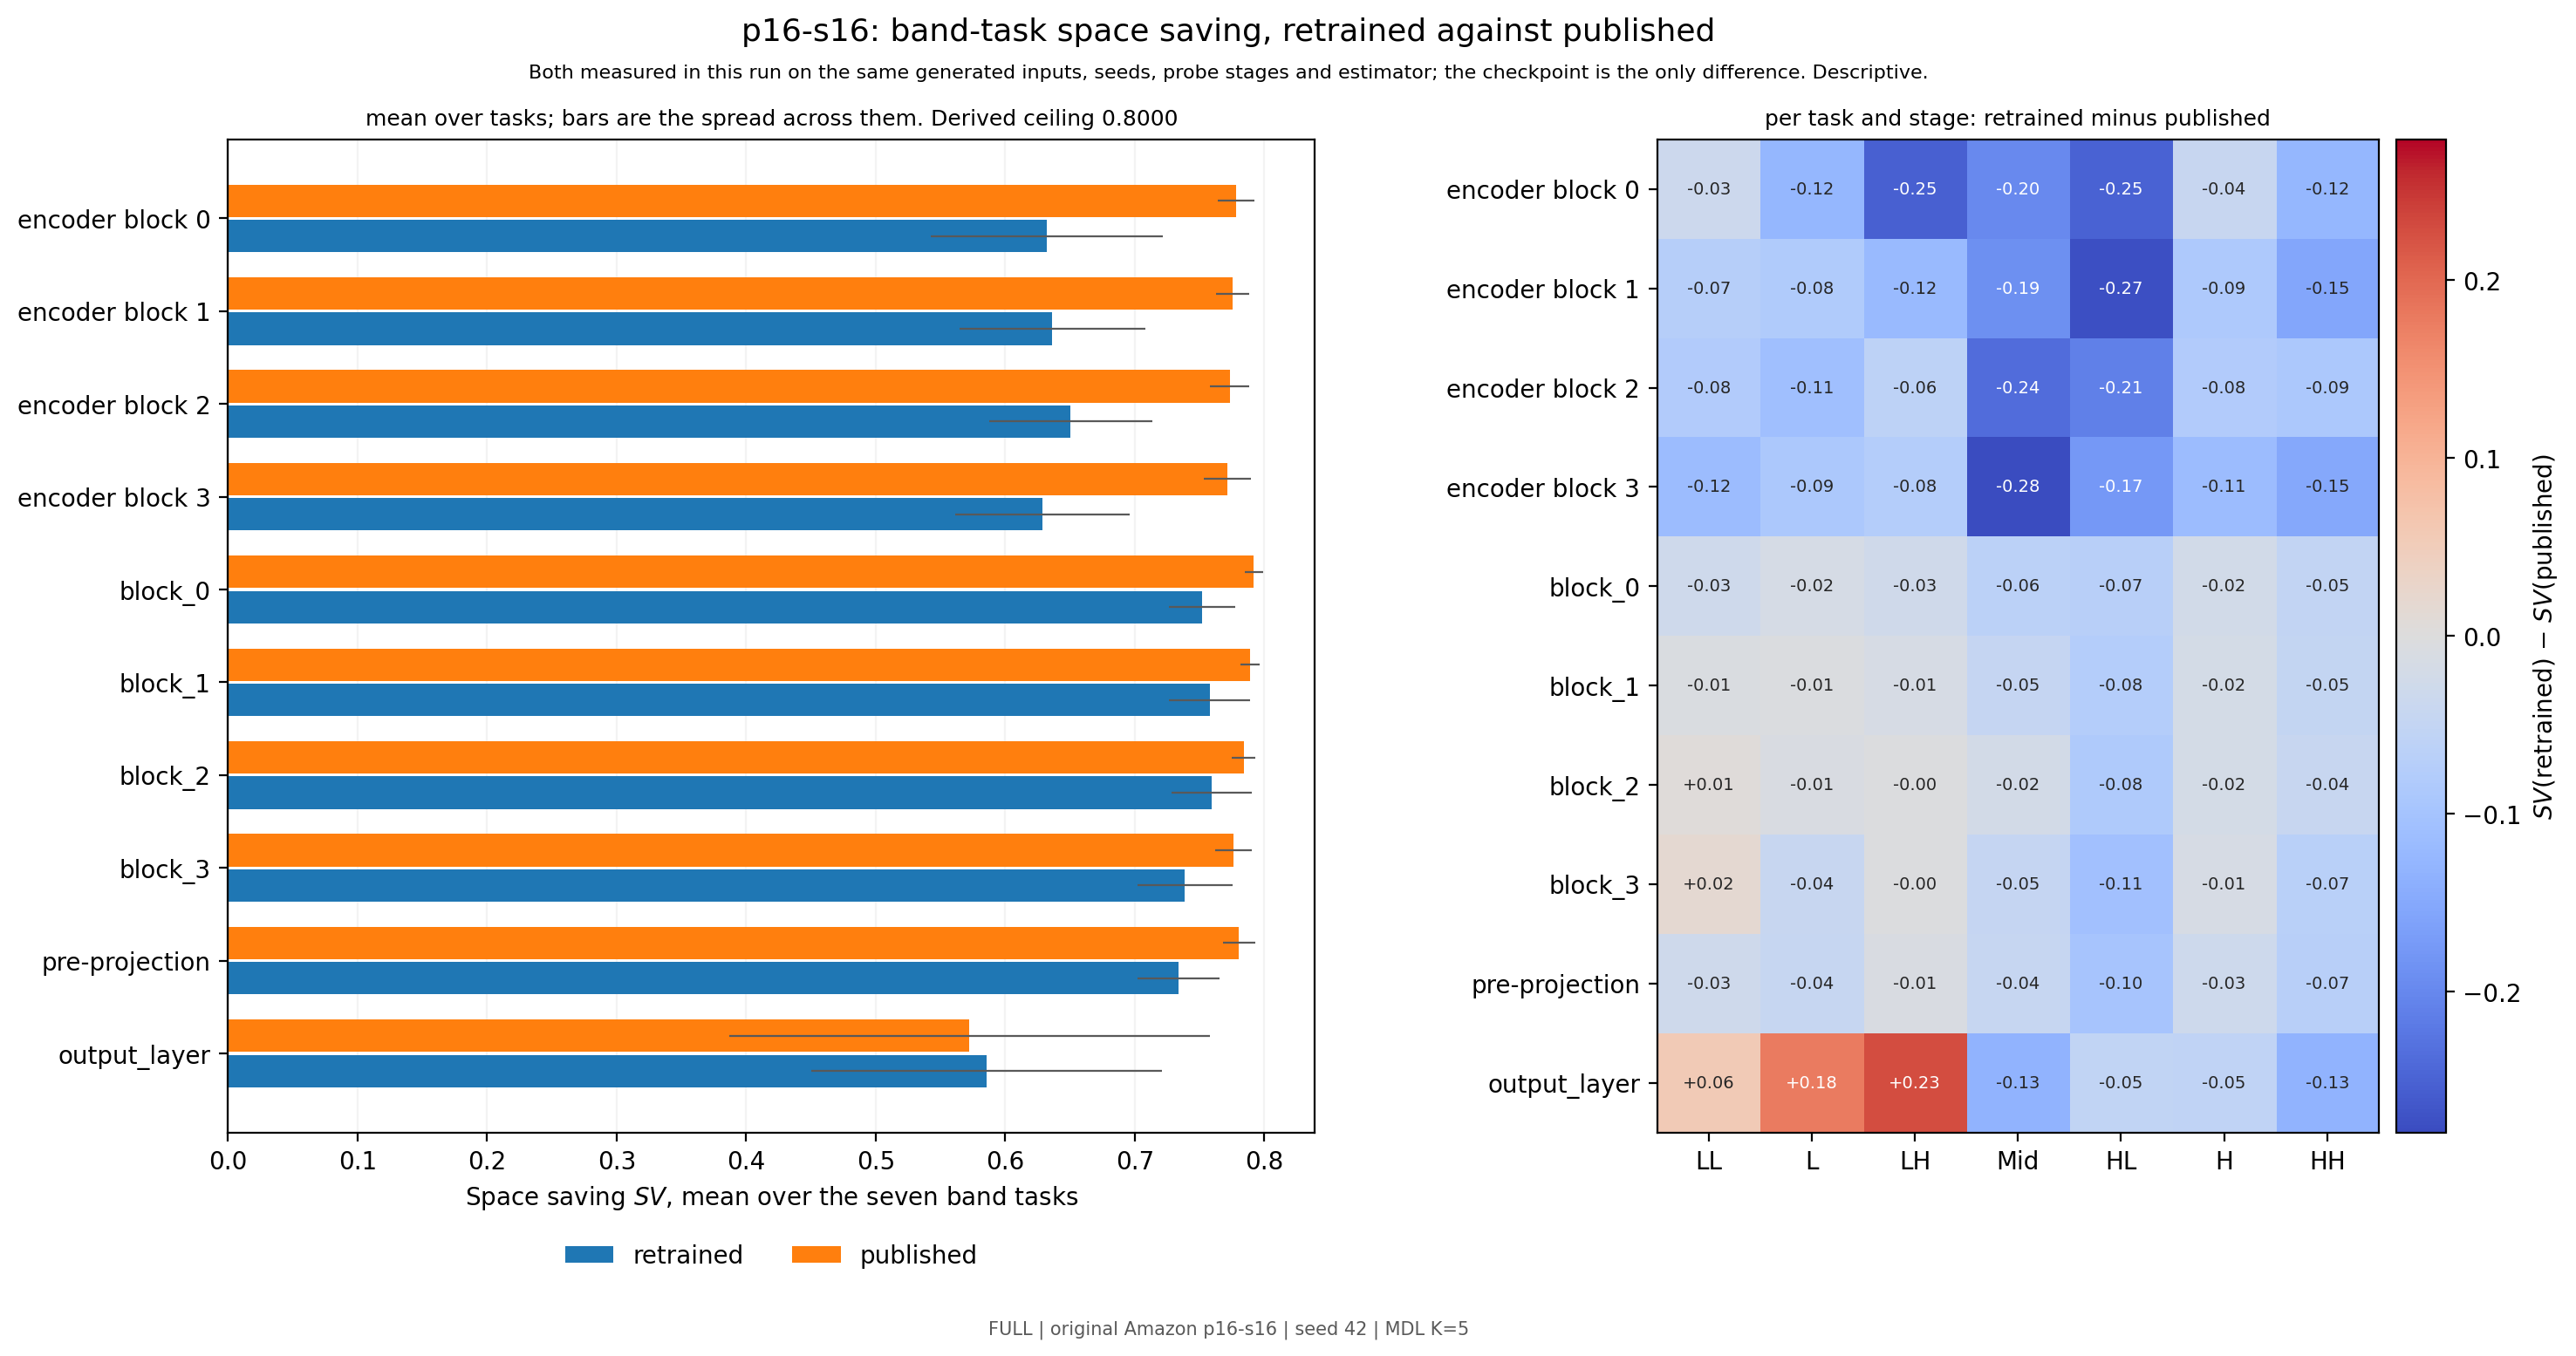

In [48]:
def paired_page(tables=None, geometry=GEOMETRY, fname=None):
    tables = TABLES if tables is None else tables
    first, second = PAIR_SOURCES
    grids = {}
    for src in (first, second):
        frame = tables[src]
        frame = frame[frame["model"] == geometry] if "model" in frame.columns else frame
        grids[src] = complete_grid(frame, ["stage", "task"], [ALL_STAGES, TASK_ORDER])

    fig, axes = plt.subplots(1, 2, figsize=(15.5, 7.8), gridspec_kw={"width_ratios": [1.25, 1.0]})
    ys = np.arange(len(ALL_STAGES))
    height = 0.38
    for src, off, colour in ((first, +height / 2, "tab:blue"), (second, -height / 2, "tab:orange")):
        by_stage = grids[src]["SV"].groupby(level="stage")
        mean = by_stage.mean().reindex(ALL_STAGES).to_numpy(float)
        spread = by_stage.std().reindex(ALL_STAGES).fillna(0).to_numpy(float)
        axes[0].barh(ys + off, mean, height=height * 0.92, color=colour, label=src,
                     xerr=spread, error_kw=dict(lw=0.8, ecolor="0.35"))
    axes[0].set_yticks(ys, [nice(s) for s in ALL_STAGES])
    axes[0].invert_yaxis()
    axes[0].axvline(0, color="0.4", lw=0.8)
    axes[0].set_xlabel(r"Space saving $SV$, mean over the seven band tasks")
    axes[0].grid(axis="x", alpha=0.15); axes[0].set_axisbelow(True)
    axes[0].legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.09), ncol=2)
    axes[0].set_title("mean over tasks; bars are the spread across them", fontsize=9)

    ceiling = ceiling_reference(grids[first])
    if ceiling is not None:
        axes[0].set_title(f"mean over tasks; bars are the spread across them. "
                          f"Derived ceiling {ceiling[1]:.4f}", fontsize=9)

    diff = (grids[first]["SV"] - grids[second]["SV"]).unstack("task")
    diff = diff.reindex(index=ALL_STAGES, columns=TASK_ORDER)
    values = diff.to_numpy(float)
    lim = float(np.nanmax(np.abs(values))) or 1.0
    im = axes[1].imshow(values, cmap="coolwarm", vmin=-lim, vmax=lim, aspect="auto")
    axes[1].set_xticks(range(len(TASK_ORDER)), TASK_ORDER)
    axes[1].set_yticks(range(len(ALL_STAGES)), [nice(s) for s in ALL_STAGES])
    for i in range(len(ALL_STAGES)):
        for j in range(len(TASK_ORDER)):
            axes[1].annotate(f"{values[i, j]:+.2f}", (j, i), ha="center", va="center", fontsize=7,
                             color="0.15" if abs(values[i, j]) < lim * 0.6 else "white")
    fig.colorbar(im, ax=axes[1], pad=0.02, label=f"$SV$({first}) $-$ $SV$({second})")
    axes[1].set_title(f"per task and stage: {first} minus {second}", fontsize=9)

    fig.suptitle(f"{geometry}: band-task space saving, {first} against {second}", fontsize=13, y=0.98)
    fig.text(0.5, 0.935, "Both measured in this run on the same generated inputs, seeds, probe "
             "stages and estimator; the checkpoint is the only difference. Descriptive.",
             ha="center", fontsize=8)
    fig.text(0.5, 0.012, SOURCE_NOTE, ha="center", fontsize=7.5, color="0.35")
    fig.subplots_adjust(left=0.13, right=0.98, top=0.89, bottom=0.16, wspace=0.35)
    return save_figure(fig, fname or f"FIG_SV_PAIRED_{geometry}.png")


paired_path = paired_page()
pd.concat([t.assign(model_source=src) for src, t in TABLES.items()], ignore_index=True) \
  .to_csv(OUT / "02_mdl_bandtasks_all_stages_both.csv", index=False)
MANIFEST.setdefault("figures", {})["paired_band_tasks"] = str(paired_path)
MANIFEST["paired_checkpoints"] = {src: CHECKPOINTS[src] for src in TABLES}
(OUT / "run_config.json").write_text(json.dumps(MANIFEST, indent=2) + "\n", encoding="utf-8")
display(Image(filename=str(paired_path)))
